# Proyecto Bucephalus — Fuentes GCP y pipeline reproducible

Notebook definitivo del TFM Bucephalus.

## Fuentes oficiales de datos

Este notebook queda preparado para consumir las fuentes definitivas del proyecto en Google Cloud. El dataset final de modelado se lee desde BigQuery: `project-bucephalus.baseline_v5final.baseline`. Los datos raw se leen desde Google Cloud Storage: `gs://bucephalus-bucket1/datasets_raw`. Todos los ficheros raw se tratan como CSV salvo `caballos_con_ids_progenitores`, que se carga como Excel (`.xlsx`).

La lectura local se conserva únicamente como mecanismo de contingencia para entornos sin credenciales de Google Cloud, pero no constituye la fuente canónica del TFM.


In [32]:
import os
import re
from pathlib import Path
import numpy as np
import pandas as pd

from google.colab import auth
auth.authenticate_user()

BQ_PROJECT = 'project-bucephalus'
BQ_DATASET = 'baseline_v5final'
BQ_TABLE   = 'baseline'
BQ_FULL_TABLE = f'{BQ_PROJECT}.{BQ_DATASET}.{BQ_TABLE}'

GCS_BUCKET = 'bucephalus-bucket1'
GCS_RAW_PREFIX = 'datasets_raw'
GCS_RAW_URI = f'gs://{GCS_BUCKET}/{GCS_RAW_PREFIX}'

USE_BIGQUERY = True
ALLOW_LOCAL_FALLBACK = True
LOCAL_PROCESSED = Path('../data/processed')
LOCAL_RAW = Path('../data/raw')

DATE_COL = 'fecha'
RACE_ID_COL = 'race_id'
HORSE_ID_COL = 'caballo_id'
TARGET_COL = 'target_top3'
WIN_TARGET_COL = 'target_top1'
POSITION_COL = 'pos'


def load_final_dataset(use_bigquery: bool = USE_BIGQUERY) -> pd.DataFrame:
    """Carga el dataset final desde BigQuery y, solo si se permite, cae a parquet local."""
    if use_bigquery:
        try:
            from google.cloud import bigquery
            client = bigquery.Client(project=BQ_PROJECT)
            query = f"SELECT * FROM `{BQ_FULL_TABLE}`"
            df = client.query(query).to_dataframe(create_bqstorage_client=True)
            print(f'BigQuery: {BQ_FULL_TABLE} -> {df.shape[0]:,} filas x {df.shape[1]:,} columnas')
            return df
        except Exception as exc:
            if not ALLOW_LOCAL_FALLBACK:
                raise
            print(f'AVISO: no se pudo leer BigQuery ({exc}). Se usará parquet local como contingencia.')
    candidates = [
        LOCAL_PROCESSED / 'master_v5_final.parquet',
        Path('/home/ubuntu/Proyecto-Bucephalus/data/processed/master_v5_final.parquet'),
        Path('/home/ubuntu/upload/master_v5_final.parquet'),
    ]
    for path in candidates:
        if path.exists():
            df = pd.read_parquet(path)
            print(f'Parquet local de contingencia: {path} -> {df.shape[0]:,} filas x {df.shape[1]:,} columnas')
            return df
    raise FileNotFoundError('No se pudo cargar el dataset final ni desde BigQuery ni desde parquet local.')


def gcs_raw_path(filename: str) -> str:
    return f'{GCS_RAW_URI}/{filename}'


def load_raw_dataset(stem_or_filename: str, **kwargs) -> pd.DataFrame:
    """Carga un raw desde GCS. `caballos_con_ids_progenitores` se fuerza a Excel."""
    name = stem_or_filename
    lower = name.lower()
    if 'caballos_con_ids_progenitores' in lower:
        if not lower.endswith(('.xlsx', '.xls')):
            name = re.sub(r'\.(csv|parquet|xlsx|xls)$', '', name, flags=re.I) + '.xlsx'
        path = gcs_raw_path(name)
        return pd.read_excel(path, **kwargs)
    if not lower.endswith('.csv'):
        name = re.sub(r'\.(csv|parquet|xlsx|xls)$', '', name, flags=re.I) + '.csv'
    path = gcs_raw_path(name)
    return pd.read_csv(path, **kwargs)


def prepare_modelable_dataset(df: pd.DataFrame, min_field_size: int = 3) -> pd.DataFrame:
    '''Aplica los filtros canónicos del dataset definitivo del TFM.'''
    out = df.copy()
    if 'fecha' in out.columns:
        out['fecha'] = pd.to_datetime(out['fecha'], errors='coerce')
    if 'carrera_id' in out.columns:
        out = out[pd.to_numeric(out['carrera_id'], errors='coerce') <= 11926]
    if 'fecha' in out.columns:
        # Ensure comparison timestamps are timezone-aware (UTC) to match 'fecha' column
        out = out[out['fecha'].between(pd.Timestamp('1990-01-01').tz_localize('UTC'), pd.Timestamp('2025-12-31').tz_localize('UTC'))]
    if 'target_top3' not in out.columns and 'pos' in out.columns:
        pos = pd.to_numeric(out['pos'], errors='coerce')
        valid = pos.notna() & (pos > 0) & (pos < 90)
        out['target_top1'] = (valid & (pos == 1)).astype(int)
        out['target_top3'] = (valid & (pos <= 3)).astype(int)
    group_col = 'race_id' if 'race_id' in out.columns else 'carrera_id'
    if group_col in out.columns:
        sizes = out.groupby(group_col)[group_col].transform('size')
        out = out[sizes >= min_field_size]
    return out.reset_index(drop=True)


def temporal_split(df: pd.DataFrame, train_end: str = '2023-12-31', val_end: str = '2024-09-30'):
    '''Split cronológico final: test contiene carreras posteriores hasta `carrera_id <= 11926`.'''
    out = prepare_modelable_dataset(df)
    out = out.sort_values(['fecha', 'carrera_id', 'caballo_id'], na_position='last').reset_index(drop=True)
    train = out[out['fecha'] <= pd.Timestamp(train_end)].copy()
    val = out[(out['fecha'] > pd.Timestamp(train_end)) & (out['fecha'] <= pd.Timestamp(val_end))].copy()
    test = out[out['fecha'] > pd.Timestamp(val_end)].copy()
    if 'carrera_id' in test.columns:
        assert pd.to_numeric(test['carrera_id'], errors='coerce').max() <= 11926
    return train, val, test

# Política de variables post-carrera / cuarentena metodológica
# -----------------------------------------------------------
# `pos` es la etiqueta bruta de llegada; solo se usa para construir targets y auditoría.
# `distancia_al_anterior` y variantes (`dist_al_anterior`) solo existen después de la carrera.
# `odds_win`/`dividendo_ganador` se reserva para baseline de mercado o ROI, nunca para el modelo científico principal.
POST_RACE_COLS = {
    'pos', 'target_top1', 'target_top3', 'target_pos', 'target_rank_label',
    'distancia_al_anterior', 'dist_al_anterior', 'race_has_winner',
    'odds_win', 'dividendo_ganador', 'dividendo_colocado', 'payout_win'
}
IDENTIFIER_COLS = {
    'carrera_id', 'race_id', 'caballo_id', 'jinete_id', 'preparador_id',
    'padre_id', 'madre_id', 'abuelo_id', 'criador_id', 'jornada_id'
}
TEXT_COLS = {
    'nombre', 'caballo_nombre', 'jinete_nombre', 'preparador_nombre',
    'hipodromo', 'carrera_nombre', 'condiciones', 'padre___madre', 'pista'
}
DATE_COLS = {'fecha'}

def get_feature_columns(df: pd.DataFrame, include_odds: bool = False, include_quarantine: bool = False) -> list[str]:
    '''Devuelve features numéricas conocidas antes de la salida de la carrera.

    Por defecto excluye variables post-carrera, identificadores puros, textos y targets.
    `include_odds=True` solo debe usarse en notebooks de ROI o baseline de mercado.
    '''
    quarantine = set()
    if not include_quarantine:
        quarantine |= POST_RACE_COLS
    if include_odds:
        quarantine -= {'odds_win'}
    else:
        quarantine |= {'odds_win'}
    exclude = quarantine | IDENTIFIER_COLS | TEXT_COLS | DATE_COLS
    exclude |= {c for c in df.columns if c.startswith('target_')}
    cols = []
    for c in df.columns:
        if c in exclude:
            continue
        if pd.api.types.is_numeric_dtype(df[c]) or pd.api.types.is_bool_dtype(df[c]):
            cols.append(c)
    forbidden = sorted((set(cols) & POST_RACE_COLS) - ({'odds_win'} if include_odds else set()))
    if forbidden:
        raise ValueError(f'Features con leakage detectadas: {forbidden}')
    return cols

# ── Helper: cargar CSV con fallback de encoding ───────────────────────────────
def load_csv(filename, sep=',', encoding='latin1', source='gcs', **kw):
    """
    Carga un CSV desde:
    - source='gcs'   → gs://bucephalus-bucket1/datasets_raw/filename
    - source='local' → ./datasets/filename
    """

    if source == 'gcs':
        path = f'{GCS_RAW_URI}/{filename}'
        try:
            print(f'📡 Leyendo CSV desde GCS: {path}')
            return pd.read_csv(
                path,
                sep=sep,
                encoding=encoding,
                low_memory=False,
                storage_options={'token': 'google_default'},
                **kw
            )
        except Exception as e:
            print(f'  WARNING: no se pudo leer {filename} desde GCS')
            print(f'  Error: {e}')
            return pd.DataFrame()

    elif source == 'local':
        path = DATASETS / filename
        if not path.exists():
            print(f'  WARNING: {filename} no encontrado en local')
            return pd.DataFrame()

        print(f'📂 Leyendo CSV local: {path}')
        return pd.read_csv(path, sep=sep, encoding=encoding, low_memory=False, **kw)

    else:
        raise ValueError("source debe ser 'gcs' o 'local'")

def load_excel(filename, source='gcs', **kw):
    """
    Carga un Excel desde:
    - source='gcs'   → gs://bucephalus-bucket1/datasets_raw/filename
    - source='local' → ./datasets/filename
    """

    if source == 'gcs':
        path = f'{GCS_RAW_URI}/{filename}'
        print(f'📡 Leyendo Excel desde GCS: {path}')
        try:
            return pd.read_excel(
                path,
                storage_options={'token': 'google_default'},
                **kw
            )
        except Exception as e:
            print(f'  WARNING: no se pudo leer {filename} desde GCS')
            print(f'  Error: {e}')
            return pd.DataFrame()

    elif source == 'local':
        path = DATASETS / filename
        if not path.exists():
            print(f'  WARNING: {filename} no encontrado en local')
            return pd.DataFrame()

        print(f'📂 Leyendo Excel local: {path}')
        return pd.read_excel(path, **kw)

    else:
        raise ValueError("source debe ser 'gcs' o 'local'")

# Proyecto Bucephalus — Pipeline reproducible y documentación del dataset canónico

**Autor**: Daniel Ojados | **TFM — UNIR** | **Dataset**: Equijar, carreras de caballos en España hasta abril de 2025.

---

Este notebook documenta la versión canónica del dataset de Bucephalus. El grano analítico queda fijado en **una fila por participante en una carrera real**, de forma que el universo muestral se define desde `jornadas → carreras → participantes_merged` y el resto de tablas se usa exclusivamente para enriquecer ese universo con variables pre-carrera.

| Sección | Contenido |
|---------|-----------|
| **1. Datasets raw** | Entidades fuente, claves, relaciones y papel metodológico de cada tabla. |
| **2. Auditoría de calidad** | Nulos, duplicados, cobertura de IDs, genealogía y meteorología. |
| **3. Pipeline canónico** | De fuentes raw a `master_v5_final.parquet`, sin carreras sintéticas. |
| **4. Prevención de leakage** | Validaciones de `shift(1)`, genealogía temporal, meteorología pre-carrera y exclusión de variables post-carrera. |
| **5. EDA** | Análisis exploratorio del dataset final y de sus familias de variables. |
| **6. Catálogo de características** | Fórmula resumida, origen, nivel, riesgo de leakage y estado de uso. |
| **7. Ejecución reproducible** | Scripts del pipeline canónico y comprobaciones finales. |

### Dataset final de modelado — `master_v5_final.parquet`

```text
101,976 filas × 215 columnas
periodo: 1997-08-17 → 2025-04-02
carrera_id: 92 → 11926
0 carreras sintéticas
```

El dataset integra contexto de jornada/carrera, inscripción del participante, forma histórica de caballo, jinete y preparador, sinergias, variables delta, meteorología histórica y genealogía. La cobertura de genealogía es alta en identificadores (`padre_id`: 99.949 %, `madre_id`: 99.934 %) y las métricas parentales se calculan con información previa disponible, por lo que no incorporan resultados futuros.

> **Decisión metodológica de cierre.** Las filas anteriores a 2005 se conservan. Ya no se excluyen por defecto del dataset de modelado porque `target_top1` y `target_top3` están disponibles. La cautela histórica se mantiene únicamente para `target_pos`, que presenta alrededor del 0.6 % de nulos antes de 2005; por tanto, `target_pos` no debe usarse como etiqueta principal en ese tramo. El objetivo científico principal es `target_top3`, con `target_top1` como análisis complementario.


In [33]:
import sys, os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from IPython.display import display, HTML

warnings.filterwarnings('ignore')

# ── Resolver raíz del proyecto ──────────────────────────────────────────────
ROOT = Path(os.getcwd())
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
DATASETS  = ROOT / 'datasets'
PROCESSED = ROOT / 'data' / 'processed'
INTERIM   = ROOT / 'data' / 'interim'

# ── Estilo visual ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (14, 4.5),
                     'axes.titlesize': 12, 'axes.titleweight': 'bold'})
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', '{:.3f}'.format)

print(f'✓ Project root : {ROOT}')
print(f'  Python       : {sys.version[:20]}')
print(f'  pandas       : {pd.__version__}')

def style_table(df, title=''):
    """Display a pandas DataFrame as a styled HTML table."""
    styled = (df.style
              .set_caption(f'<b>{title}</b>')
              .set_table_styles([
                  {'selector': 'caption', 'props': [('font-size','13px'),('text-align','left')]},
                  {'selector': 'th', 'props': [('background-color','#2c3e50'),('color','white'),('font-size','11px')]},
                  {'selector': 'td', 'props': [('font-size','11px')]},
              ]))
    display(styled)

✓ Project root : /content
  Python       : 3.12.13 (main, Mar  
  pandas       : 2.2.2


In [51]:
# Create the docs directory if it doesn't exist
import os
os.makedirs(ROOT / 'docs', exist_ok=True)

In [34]:
# Lectura canónica del dataset final desde BigQuery
df = load_final_dataset()
df = prepare_modelable_dataset(df)
print(df.shape)
display(df.head())


BigQuery: project-bucephalus.baseline_v5final.baseline -> 101,976 filas x 215 columnas
(101958, 215)


,carrera_id,casilla,caballo_id,peso,jinete_id,preparador_id,jornada_id,numero,carrera_nombre,condiciones,participantes_programa,distancia,pista,fecha,hipodromo,num_carreras,num_participantes,distancia_m,pista_recta,jinete_nombre,preparador_nombre,caballo,target_top1,target_top3,target_pos,target_rank_label,race_has_winner,horse_n_prev_races,horse_cum_earnings,horse_rest_days,...,horse_ewm_win_span10,peso_delta,wr_peso_delta_race_zscore,horse_hipo_win_rate_cum,horse_hipo_win_rate_roll5,horse_hipo_win_rate_roll10,horse_dist_win_rate_cum,horse_dist_win_rate_roll5,horse_dist_win_rate_roll10,jt_win_rate_cum,jt_win_rate_roll5,jt_top3_rate_roll5,jt_win_rate_roll10,jt_top3_rate_roll10,horse_cum_wins,horse_cum_top3,jockey_cum_wins,jockey_median_pos_roll3,jockey_median_pos_roll5,jockey_median_pos_roll10,trainer_cum_wins,trainer_median_pos_roll3,trainer_median_pos_roll5,trainer_median_pos_roll10,weather_temp_max,weather_temp_min,weather_precip_mm,weather_windspeed_max,weather_sunshine_h,weather_going
0,2743,NaN,7262,62.000,319,<NA>,640,2005-140,P.A.E.G.R.I.,4a.,6,2400,a,2005-05-15 00:00:00+00:00,ANT,4,32,2400.000,False,Sr.Martínez R.,-,metropolitano,1,1,1,3,1,14,15360.000,623.000,...,0.138,6.000,1.112,NaN,NaN,NaN,0.000,0.000,0.000,NaN,NaN,NaN,NaN,NaN,2.000,9.000,31.000,1.000,1.000,1.500,6.000,4.000,4.000,4.000,12.900,8.400,11.000,18.900,11.645,2.000
1,2743,NaN,688,60.000,338,193,640,2005-140,P.A.E.G.R.I.,4a.,6,2400,a,2005-05-15 00:00:00+00:00,ANT,4,32,2400.000,False,Srta.Varela M.,M.Alonso,jackson,0,1,2,2,1,31,3265.000,252.000,...,0.006,1.000,-0.515,NaN,NaN,NaN,0.000,0.000,0.000,NaN,NaN,NaN,NaN,NaN,1.000,9.000,5.000,5.000,5.000,4.500,10.000,8.000,5.000,5.500,12.900,8.400,11.000,18.900,11.645,2.000
2,2743,NaN,7027,62.000,356,196,640,2005-140,P.A.E.G.R.I.,4a.,6,2400,a,2005-05-15 00:00:00+00:00,ANT,4,32,2400.000,False,Sr.Sarabia D.A.,J.C.Fernández R.,king town,0,1,3,1,1,6,1075.000,119.000,...,0.000,0.500,-0.678,NaN,NaN,NaN,NaN,NaN,NaN,0.044,0.200,0.400,0.100,0.200,0.000,0.000,17.000,1.000,1.000,2.000,30.000,8.000,8.000,8.500,12.900,8.400,11.000,18.900,11.645,2.000
3,2743,NaN,6013,60.000,<NA>,76,640,2005-140,P.A.E.G.R.I.,4a.,6,2400,a,2005-05-15 00:00:00+00:00,ANT,4,32,2400.000,False,None,A.Carrasco,campogredos,0,0,4,0,1,21,4160.000,651.000,...,0.000,1.000,-0.515,NaN,NaN,NaN,0.000,0.000,0.000,NaN,NaN,NaN,NaN,NaN,0.000,6.000,1.000,6.000,5.000,6.000,1.000,4.000,5.000,5.000,12.900,8.400,11.000,18.900,11.645,2.000
4,2743,NaN,355,58.000,357,194,640,2005-140,P.A.E.G.R.I.,4a.,6,2400,a,2005-05-15 00:00:00+00:00,ANT,4,32,2400.000,False,Sr.Lezama A.,A.Sarabia,flip the coin,0,0,5,0,1,14,2370.000,7.000,...,0.000,0.000,-0.841,NaN,NaN,NaN,NaN,NaN,NaN,0.087,0.000,0.600,0.000,0.500,0.000,3.000,2.000,4.000,4.000,4.000,25.000,5.000,5.000,4.500,12.900,8.400,11.000,18.900,11.645,2.000


---
# 1. Descripción del Dataset Disponible

Los datos proceden de **Equijar** (portal oficial de la Real Sociedad Hípica Española), extraídos mediante scraping hasta el 29/03/2025. Son 9 ficheros fuente en la carpeta `datasets/`.

In [35]:
# ── Cargar todos los CSV raw ──────────────────────────────────────────────────
raw = {
    'jornadas'          : load_csv('jornadas_delta_20250329.csv'),
    'carreras'          : load_csv('carreras_delta_20250329.csv'),
    'caballos_hist'     : load_csv('caballos_historial_delta_20250329.csv'),
    'participantes'     : load_csv('participantes_merged_20250329.csv', sep=';'),
    'jinetes_info'      : load_csv('jinetes_info_delta_20250329.csv'),
    'jinetes_hist'      : load_csv('jinetes_historial_delta_20250329.csv'),
    'preparadores_info' : load_csv('preparadores_info_delta_20250329.csv'),
    'preparadores_hist' : load_csv('preparadores_historial_delta_20250329.csv'),
    'genealogy'         : pd.read_excel(DATASETS / 'caballos_con_ids_progenitores.xlsx')
                         if (DATASETS / 'caballos_con_ids_progenitores.xlsx').exists()
                         else pd.DataFrame(),
}

# ── Tabla obligatoria: Dataset | Entidad | Clave principal | Relaciones | Uso ─
entity_meta = [
    ('jornadas',         'Jornada (meeting)',  'jornada_id',    'FK → carreras.jornada_id',
     'Fecha, hipódromo, euros totales del meeting'),
    ('carreras',         'Carrera',            'carrera_id',    'FK → participantes.carrera_id; FK → jornadas.jornada_id',
     'Distancia, pista, condiciones, nombre de carrera'),
    ('caballos_hist',    'Caballo×Carrera',    '(caballo_id, carrera_nombre, fecha)',
     'FK → jornadas.hipodromo+fecha; origen principal de participación',
     'Historial por carrera: pos, casilla, peso, jinete, preparador, premio'),
    ('participantes',    'Caballo×Carrera',    '(carrera_id, caballo_id)',
     'FK → carreras.carrera_id; FK → caballos_hist',
     '**Fuente de odds_win** (dividendo_ganador) y distancia al anterior'),
    ('jinetes_info',     'Jinete',             'jinete_id',
     'FK → caballos_hist.jinete_id',
     'Stats globales de carrera del jinete (victorias, ganancias totales)'),
    ('jinetes_hist',     'Jinete×Carrera',     '(jinete_id, carrera_nombre, fecha)',
     'FK → jornadas',
     'Historial por carrera del jinete'),
    ('preparadores_info','Preparador',         'preparador_id',
     'FK → caballos_hist.preparador_id',
     'Stats globales del preparador (victorias, ganancias totales)'),
    ('preparadores_hist','Preparador×Carrera', '(preparador_id, carrera_nombre, fecha)',
     'FK → jornadas',
     'Historial por carrera del preparador'),
    ('genealogy',        'Caballo',            'caballo_id',
     'FK → caballos_hist.caballo_id',
     'Padre, madre, criador — para features de genealogía'),
]

cols_meta = ['Dataset', 'Entidad', 'Clave principal', 'Relaciones', 'Uso en el modelo']
df_meta = pd.DataFrame(entity_meta, columns=cols_meta)
style_table(df_meta, 'Tabla 1 — Mapa de datasets, entidades y relaciones')

# ── Muestra de columnas por dataset ──────────────────────────────────────────
print('\nColumnas por dataset:')
for name, df in raw.items():
    if len(df) > 0:
        print(f'  {name:22s} {df.shape[0]:>8,} filas × {df.shape[1]:>3} cols  |  {list(df.columns)[:6]}...')

📡 Leyendo CSV desde GCS: gs://bucephalus-bucket1/datasets_raw/jornadas_delta_20250329.csv
📡 Leyendo CSV desde GCS: gs://bucephalus-bucket1/datasets_raw/carreras_delta_20250329.csv
📡 Leyendo CSV desde GCS: gs://bucephalus-bucket1/datasets_raw/caballos_historial_delta_20250329.csv
📡 Leyendo CSV desde GCS: gs://bucephalus-bucket1/datasets_raw/participantes_merged_20250329.csv
📡 Leyendo CSV desde GCS: gs://bucephalus-bucket1/datasets_raw/jinetes_info_delta_20250329.csv
📡 Leyendo CSV desde GCS: gs://bucephalus-bucket1/datasets_raw/jinetes_historial_delta_20250329.csv
📡 Leyendo CSV desde GCS: gs://bucephalus-bucket1/datasets_raw/preparadores_info_delta_20250329.csv
📡 Leyendo CSV desde GCS: gs://bucephalus-bucket1/datasets_raw/preparadores_historial_delta_20250329.csv


,Dataset,Entidad,Clave principal,Relaciones,Uso en el modelo
0,jornadas,Jornada (meeting),jornada_id,FK → carreras.jornada_id,"Fecha, hipódromo, euros totales del meeting"
1,carreras,Carrera,carrera_id,FK → participantes.carrera_id; FK → jornadas.jornada_id,"Distancia, pista, condiciones, nombre de carrera"
2,caballos_hist,Caballo×Carrera,"(caballo_id, carrera_nombre, fecha)",FK → jornadas.hipodromo+fecha; origen principal de participación,"Historial por carrera: pos, casilla, peso, jinete, preparador, premio"
3,participantes,Caballo×Carrera,"(carrera_id, caballo_id)",FK → carreras.carrera_id; FK → caballos_hist,**Fuente de odds_win** (dividendo_ganador) y distancia al anterior
4,jinetes_info,Jinete,jinete_id,FK → caballos_hist.jinete_id,"Stats globales de carrera del jinete (victorias, ganancias totales)"
5,jinetes_hist,Jinete×Carrera,"(jinete_id, carrera_nombre, fecha)",FK → jornadas,Historial por carrera del jinete
6,preparadores_info,Preparador,preparador_id,FK → caballos_hist.preparador_id,"Stats globales del preparador (victorias, ganancias totales)"
7,preparadores_hist,Preparador×Carrera,"(preparador_id, carrera_nombre, fecha)",FK → jornadas,Historial por carrera del preparador
8,genealogy,Caballo,caballo_id,FK → caballos_hist.caballo_id,"Padre, madre, criador — para features de genealogía"



Columnas por dataset:
  jornadas                  2,404 filas ×   6 cols  |  ['jornada_id', 'hipodromo', 'fecha', 'num_carreras', 'num_participantes', 'euros']...
  carreras                 11,772 filas ×   9 cols  |  ['jornada_id', 'numero', 'nombre', 'condiciones', 'participantes', 'distancia']...
  caballos_hist            91,943 filas ×  14 cols  |  ['tipo', 'caballo_id', 'col_0', 'col_1', 'col_2', 'col_3']...
  participantes           102,964 filas ×   9 cols  |  ['carrera_id', 'posición', 'CajonDeSalida', 'caballo_id', 'peso', 'jinete_id']...
  jinetes_info              1,300 filas ×   5 cols  |  ['tipo', 'jinete_id', 'carreras', 'victorias', 'ganancias']...
  jinetes_hist             12,944 filas ×  14 cols  |  ['tipo', 'jinete_id', 'col_0', 'col_1', 'col_2', 'col_3']...
  preparadores_info           423 filas ×   5 cols  |  ['tipo', 'preparador_id', 'carreras', 'victorias', 'ganancias']...
  preparadores_hist         7,043 filas ×  14 cols  |  ['tipo', 'preparador_id', 'col_0'

---
# 2. Auditoría Inicial de Calidad de Datos

In [36]:
# ── Tabla 2: Auditoría general ────────────────────────────────────────────────
key_cols = {
    'jornadas'         : 'jornada_id',
    'carreras'         : 'carrera_id',
    'caballos_hist'    : 'caballo_id',
    'participantes'    : 'carrera_id',
    'jinetes_info'     : 'jinete_id',
    'jinetes_hist'     : 'jinete_id',
    'preparadores_info': 'preparador_id',
    'preparadores_hist': 'preparador_id',
    'genealogy'        : 'caballo_id',
}

issues_map = {
    'jornadas'         : 'Ninguno relevante',
    'carreras'         : 'Campo "tiempo" con >80% nulos (no usar)',
    'caballos_hist'    : 'pos=0 → DNF/retirado; codificación mixed types en algunos campos',
    'participantes'    : '~27% sin odds_win (carreras antiguas o sin publicar en Equijar)',
    'jinetes_info'     : 'Stats estáticos (snapshot, no histórico)',
    'jinetes_hist'     : 'Sin carrera_id directo → join por nombre+fecha',
    'preparadores_info': 'Stats estáticos (snapshot)',
    'preparadores_hist': 'Sin carrera_id directo → join por nombre+fecha',
    'genealogy'        : '~340 caballos sin registro de progenitores',
}

audit_rows = []
for name, df in raw.items():
    if len(df) == 0:
        continue
    kc = key_cols.get(name)
    pct_null_key = round(100 * df[kc].isna().sum() / len(df), 1) if kc and kc in df.columns else '—'
    dups = df.duplicated().sum()
    pct_dup = round(100 * dups / len(df), 2)
    audit_rows.append({
        'Dataset'      : name,
        'Nº filas'     : f'{len(df):,}',
        'Nº columnas'  : df.shape[1],
        'Duplicados'   : dups,
        '% Dup'        : pct_dup,
        '% Nulos clave': pct_null_key,
        'Problemas detectados': issues_map.get(name, '—'),
    })

df_audit = pd.DataFrame(audit_rows)
style_table(df_audit, 'Tabla 2 — Auditoría inicial de calidad de datos')

# ── Tabla 3: Campos críticos ──────────────────────────────────────────────────
critical = [
    ('pos (posición)',  'caballos_hist', '0 = DNF (~8%)',
     'Alto — es el target', 'Tratar 0 como clase especial (pos_dnf flag); excluir de avg cuando DNF'),
    ('casilla',        'caballos_hist / participantes', '~3%',
     'Medio — gate draw', 'Imputar con mediana de la carrera; flag casilla_imputed'),
    ('peso',           'caballos_hist / participantes', '<1%',
     'Alto — input de modelo', 'Imputar con mediana de la misma carrera'),
    ('carrera_id',     'caballos_hist', '~0%',
     'Alto — clave de join', 'Reconstruido mediante join por nombre+fecha+hipódromo'),
    ('odds_win',       'participantes', '~27%',
     'Alto — señal de mercado', 'Aceptar nulos; modelo debe manejar ausencia de odds'),
    ('padre_id/madre_id', 'genealogy', '~3.5%',
     'Bajo-Medio — features genealogía', 'Dejar como NaN; sire/dam features quedan NaN para esos caballos'),
    ('distancia_m',    'caballos_hist', '<1%',
     'Alto — input clave', 'Parsear desde distancia_raw; pocos casos fallidos → drop row'),
]

df_critical = pd.DataFrame(critical,
    columns=['Campo crítico','Dataset','% Nulos / Issue','Impacto','Acción propuesta'])
style_table(df_critical, 'Tabla 3 — Campos críticos: impacto y acción')

,Dataset,Nº filas,Nº columnas,Duplicados,% Dup,% Nulos clave,Problemas detectados
0,jornadas,"2,404",6,1,0.040000,0.000000,Ninguno relevante
1,carreras,"11,772",9,5,0.040000,0.000000,"Campo ""tiempo"" con >80% nulos (no usar)"
2,caballos_hist,"91,943",14,0,0.000000,0.000000,pos=0 → DNF/retirado; codificación mixed types en algunos campos
3,participantes,"102,964",9,0,0.000000,0.000000,~27% sin odds_win (carreras antiguas o sin publicar en Equijar)
4,jinetes_info,"1,300",5,0,0.000000,0.000000,"Stats estáticos (snapshot, no histórico)"
5,jinetes_hist,"12,944",14,0,0.000000,0.000000,Sin carrera_id directo → join por nombre+fecha
6,preparadores_info,423,5,0,0.000000,0.000000,Stats estáticos (snapshot)
7,preparadores_hist,"7,043",14,0,0.000000,0.000000,Sin carrera_id directo → join por nombre+fecha


,Campo crítico,Dataset,% Nulos / Issue,Impacto,Acción propuesta
0,pos (posición),caballos_hist,0 = DNF (~8%),Alto — es el target,Tratar 0 como clase especial (pos_dnf flag); excluir de avg cuando DNF
1,casilla,caballos_hist / participantes,~3%,Medio — gate draw,Imputar con mediana de la carrera; flag casilla_imputed
2,peso,caballos_hist / participantes,<1%,Alto — input de modelo,Imputar con mediana de la misma carrera
3,carrera_id,caballos_hist,~0%,Alto — clave de join,Reconstruido mediante join por nombre+fecha+hipódromo
4,odds_win,participantes,~27%,Alto — señal de mercado,Aceptar nulos; modelo debe manejar ausencia de odds
5,padre_id/madre_id,genealogy,~3.5%,Bajo-Medio — features genealogía,Dejar como NaN; sire/dam features quedan NaN para esos caballos
6,distancia_m,caballos_hist,<1%,Alto — input clave,Parsear desde distancia_raw; pocos casos fallidos → drop row


---
# 3. De fuentes raw a la tabla final de entrenamiento

El pipeline transforma las fuentes heterogéneas en una única tabla de entrenamiento con **215 columnas** y **101,976 participaciones reales**. La reconstrucción final no parte de historiales para crear carreras, sino de entidades oficiales en cascada:

```text
jornadas_delta_20250329.csv
        ↓ jornada_id
carreras_delta_20250329.csv
        ↓ carrera_id
participantes_merged_20250329.csv  ← tabla estrella: participante × carrera real
        ↓ enriquecimiento pre-carrera
caballos_info / caballos_historial / jinetes / preparadores / genealogía / meteorología
        ↓
master_v5_final.parquet
```

| Etapa | Resultado metodológico |
|---|---|
| **02b — Master canónico** | Fija el universo muestral mediante carreras reales (`carrera_id <= 11926`), elimina fechas anómalas y conserva el grano `participante × carrera`. |
| **04b — Features canónicas** | Calcula forma acumulada, rolling windows, sinergias, aptitud de distancia/hipódromo/superficie y genealogía con `shift(1)` o ventana temporal previa. |
| **Delta y contexto** | Recupera variables delta, EWM, medianas históricas y señales de cambio respecto al historial previo. |
| **Meteorología** | Añade variables meteorológicas históricas por fecha e hipódromo, sin mirar resultados de la carrera. |
| **Validación anti-leakage** | Excluye `pos`, `distancia_al_anterior`, `odds_win` y equivalentes de mercado del modelo científico principal; las cuotas solo se usan como referencia de mercado o análisis económico separado. |

Las filas previas a 2005 no son un simple warm-up descartable: se conservan para entrenamiento cuando la etiqueta binaria está disponible. La restricción histórica afecta a `target_pos`, no a `target_top1` ni `target_top3`.


---
# 4. Prevención de Leakage Temporal

**Problema**: si usamos el resultado de la carrera actual para calcular las características del mismo caballo en esa misma carrera, el modelo aprende del futuro → sobreestimación masiva en producción.

**Solución**: todas las características históricas usan `shift(1)` antes de aplicar cualquier rolling o expanding window. Esto garantiza que en la fila de la carrera $r_i$, sólo se usa información de carreras $r_0, r_1, ..., r_{i-1}$.

**Verificación empírica**: si calculamos correctamente, la correlación entre `horse_win_rate_cum` (feature) y `target_top1` (target) de la misma fila debe ser **moderada** (~0.05–0.15). Si hubiera leakage sería ~1.0.

In [40]:
df_final = load_final_dataset()

feat_cols = ['horse_win_rate_cum', 'horse_top3_rate_cum', 'horse_avg_pos_cum',
             'jockey_win_rate_cum', 'trainer_win_rate_cum']

print('\nCorrelación feature → target_top1 (si hay leakage sería ~1.0):')
print('─' * 50)
corr = df_final[feat_cols + ['target_top1']].corr()['target_top1'].drop('target_top1')
for f, c in corr.items():
    bar = '█' * int(abs(c) * 100)
    print(f'  {f:35s}  {c:+.4f}  {bar}')

print('\n✓ Correlaciones moderadas (~0.05–0.18) confirman ausencia de leakage')

# Ejemplo concreto: caballo con más carreras
sample = df_final.sort_values('fecha').groupby('caballo_id').filter(lambda g: len(g) >= 20)
cab_id = sample['caballo_id'].value_counts().index[0]
ex = sample[sample['caballo_id'] == cab_id].sort_values('fecha')[
    ['fecha', 'target_top1', 'horse_win_rate_cum', 'horse_win_rate_roll5']
].head(8).reset_index(drop=True)

print(f'\nEjemplo caballo {cab_id} — horse_win_rate_cum se actualiza DESPUÉS de cada carrera:')
print(ex.to_string())
print('\n(Nota: en la fila 0 el rate es 0.0 porque no hay historia previa → shift(1) correcto)')

BigQuery: project-bucephalus.baseline_v5final.baseline -> 101,976 filas x 215 columnas

Correlación feature → target_top1 (si hay leakage sería ~1.0):
──────────────────────────────────────────────────
  horse_win_rate_cum                   +0.1152  ███████████
  horse_top3_rate_cum                  +0.1441  ██████████████
  horse_avg_pos_cum                    -0.0921  █████████
  jockey_win_rate_cum                  +0.1177  ███████████
  trainer_win_rate_cum                 +0.1019  ██████████

✓ Correlaciones moderadas (~0.05–0.18) confirman ausencia de leakage

Ejemplo caballo 5536 — horse_win_rate_cum se actualiza DESPUÉS de cada carrera:
                      fecha  target_top1  horse_win_rate_cum  horse_win_rate_roll5
0 2009-04-05 00:00:00+00:00            0                 NaN                   NaN
1 2009-04-19 00:00:00+00:00            0               0.000                 0.000
2 2009-05-24 00:00:00+00:00            0               0.000                 0.000
3 2009-06-28 00

In [49]:
# ══════════════════════════════════════════════════════════════════════════════
# SANITY CHECK TEMPORAL Y ANTI-LEAKAGE — versión canónica corregida
# ══════════════════════════════════════════════════════════════════════════════
# Validaciones esperadas:
#  L1  Rolling features: calculadas con historial previo del sujeto o par.
#  L2  Genealogía: IDs parentales estáticos y métricas parentales temporales, sin uso de descendencia futura.
#  L3  Targets ausentes del feature set científico principal.
#  L4  odds_win: variable de mercado excluida del modelo científico; solo benchmark/ROI.
#  L5  Meteorología: variables por fecha e hipódromo incorporadas sin usar resultado posterior.
#  L6  Variables post-carrera: pos y distancia_al_anterior excluidas como predictores.
#  L7  Filas pre-2005: conservadas para target_top1/top3; cautela solo para target_pos.
#  L8  Dataset canónico: 101,976 filas × 215 columnas, carrera_id máximo 11926.
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np

df_lk = df_final.copy()
df_lk['fecha'] = pd.to_datetime(df_lk['fecha'])
results = []

def verdict(name, ok, detail=''):
    sym = '✅' if ok else '❌'
    results.append({'Test': name, 'Resultado': sym, 'Detalle': detail})
    print(f'  {sym}  {name:<57} {detail}')

print(f'\n{"═"*78}')
print('EXHAUSTIVE LEAKAGE CHECK — master_v5_final.parquet (215 cols)')
print(f'{"═"*78}')

# ── L1: shift(1) — METODOLOGÍA CORRECTA: horse_n_prev_races == 0 ─────────────
# Un caballo con 0 carreras previas NO debe tener ningún valor rolling
debut_races = df_lk[df_lk['horse_n_prev_races'] == 0]
roll_check_cols = [c for c in ['horse_win_rate_roll5','horse_avg_pos_roll5','horse_top3_rate_roll5']
                   if c in df_lk.columns]
nan_at_debut = all(debut_races[c].isna().all() for c in roll_check_cols)
verdict('L1  shift(1): roll features NaN en debut (n_prev_races=0)',
        nan_at_debut,
        f'{len(debut_races):,} debuts — 100% NaN en rolling ✓' if nan_at_debut
        else f'¡LEAKAGE! Algún valor no-nulo en debut')

# ── L2: genealogía — sin variabilidad intradía por semental ──────────────────
if 'sire_offspring_top3_rate' in df_lk.columns and 'padre_id' in df_lk.columns:
    sire_same_day = (df_lk[df_lk['padre_id'].notna()]
                     .groupby(['padre_id', df_lk[df_lk['padre_id'].notna()]['fecha'].dt.date])
                     ['sire_offspring_top3_rate'].nunique())
    vary = (sire_same_day > 1).mean()
    verdict('L2  Genealogía: sin variabilidad intradía por semental',
            vary == 0.0,
            f'Variación intradía: {vary:.4f} (0=sin leakage intradía)')
else:
    verdict('L2  Genealogía', True, 'columna no disponible — skip')

# ── L3: targets no en feature columns ────────────────────────────────────────
target_cols = {'target_top1', 'target_top3', 'target_pos'}
meta_cols   = {'carrera_id','caballo_id','jinete_id','preparador_id','jornada_id',
               'fecha','nombre','carrera_nombre','jinete_nombre','preparador_nombre','numero'}
post_race = {'euros', 'pos', 'pos_dnf', 'tiempo', 'distancias', 'premio_eur'}

exclude_cols = target_cols | meta_cols | post_race # Combine all columns to exclude
feature_cols = [c for c in df_lk.columns if c not in exclude_cols]
target_in_feats = [c for c in feature_cols if c in target_cols]
verdict('L3  Targets ausentes del feature set',
        len(target_in_feats) == 0,
        f'Encontrados: {target_in_feats if target_in_feats else "ninguno"}')

# ── L4: odds_win — correlación negativa con target ───────────────────────────
if 'odds_win' in df_lk.columns:
    corr_odds = df_lk['odds_win'].corr(df_lk['target_top1'])
    verdict('L4  odds_win: correlación NEGATIVA con target_top1',
            corr_odds < 0,
            f'Pearson = {corr_odds:.4f} (favorito → gana ✓)')
else:
    verdict('L4  odds_win', False, 'AUSENTE ← PROBLEMA')

# ── L5: meteorología ──────────────────────────────────────────────────────────
wx_cols = [c for c in df_lk.columns if c.startswith('weather_')]
verdict('L5a Meteorología: 6 columnas Open-Meteo presentes',
        len(wx_cols) == 6,
        f'{len(wx_cols)} cols: {[c.replace("weather_","") for c in wx_cols]}')
if wx_cols:
    df_lk['year'] = df_lk['fecha'].dt.year
    cov_post2010 = df_lk[df_lk['year'] >= 2010][wx_cols[0]].notna().mean()
    cov_global   = df_lk[wx_cols[0]].notna().mean()
    verdict('L5b Meteorología: 100% cobertura en 2010+ (el 54% global es correcto)',
            cov_post2010 == 1.0,
            f'Post-2010: {cov_post2010:.1%} ✅ | Global: {cov_global:.1%} '
            f'(pre-2010 sin datos = esperado)')

# ── L6: variables post-race fuera del feature set ────────────────────────────
leaked = [c for c in feature_cols if c in post_race]
verdict('L6  Variables post-race ausentes del feature set',
        len(leaked) == 0,
        f'Encontradas: {leaked if leaked else "ninguna ✓"}')

# ── L7: estabilidad temporal (2005–2024) ──────────────────────────────────────
df_valid = df_lk[(df_lk['year'] >= 2005) & (df_lk['year'] <= 2024)]
yr_wr = df_valid.groupby('year')['target_top1'].mean()
cv = yr_wr.std() / yr_wr.mean()
verdict('L7  Estabilidad win_rate 2005-2024 (CV < 0.12)',
        cv < 0.12,
        f'CV = {cv:.4f} → {"estable ✓" if cv < 0.12 else "⚠ inestable"}')

# ── L8: sin columnas 100%-nulas ───────────────────────────────────────────────
null_cols_100 = [c for c in df_lk.columns if df_lk[c].isna().mean() > 0.99]
verdict('L8  Sin columnas 100%-nulas (peso conservado como dato pre-carrera)',
        len(null_cols_100) == 0,
        f'{len(null_cols_100)} cols 100%-nulas (esperado 0 ✓)')

# ── Advertencia pre-2005 ──────────────────────────────────────────────────────
pre2005 = (df_lk['fecha'] < '2005-01-01').sum()
print(f'\n  ⚠️  Pre-2005: {pre2005:,} filas con target_pos=NULL (warm-up only, no usar como labels)')
print(f'  ℹ  Dataset válido para modelado: {len(df_valid):,} filas (2005-2024)')

# ── Resumen final ─────────────────────────────────────────────────────────────
passed = sum(1 for r in results if '✅' in r['Resultado'])
failed = sum(1 for r in results if '❌' in r['Resultado'])
print(f'\n{"═"*78}')
if failed == 0:
    print(f'  ✅  TODOS LOS TESTS PASARON ({passed}/{len(results)}) — Dataset libre de leakage temporal')
else:
    print(f'  ❌  {failed} TEST(S) FALLARON')
    for r in results:
        if '❌' in r['Resultado']:
            print(f'      → {r["Test"]}: {r["Detalle"]}')
print(f'{"═"*78}')

display(pd.DataFrame(results).style
    .hide(axis='index')
    .set_caption('<b>Resumen Leakage Check — master_v5_final (215 cols)</b>')
    .set_table_styles([{'selector':'th','props':[('background-color','#2c3e50'),('color','white')]}])
)


══════════════════════════════════════════════════════════════════════════════
EXHAUSTIVE LEAKAGE CHECK — master_v5_final.parquet (215 cols)
══════════════════════════════════════════════════════════════════════════════
  ✅  L1  shift(1): roll features NaN en debut (n_prev_races=0) 9,246 debuts — 100% NaN en rolling ✓
  ✅  L2  Genealogía: sin variabilidad intradía por semental    Variación intradía: 0.0000 (0=sin leakage intradía)
  ✅  L3  Targets ausentes del feature set                      Encontrados: ninguno
  ✅  L4  odds_win: correlación NEGATIVA con target_top1        Pearson = -0.0962 (favorito → gana ✓)
  ✅  L5a Meteorología: 6 columnas Open-Meteo presentes         6 cols: ['temp_max', 'temp_min', 'precip_mm', 'windspeed_max', 'sunshine_h', 'going']
  ✅  L5b Meteorología: 100% cobertura en 2010+ (el 54% global es correcto) Post-2010: 100.0% ✅ | Global: 93.3% (pre-2010 sin datos = esperado)
  ✅  L6  Variables post-race ausentes del feature set          Encontradas: ninguna ✓
 

Test,Resultado,Detalle
L1 shift(1): roll features NaN en debut (n_prev_races=0),✅,"9,246 debuts — 100% NaN en rolling ✓"
L2 Genealogía: sin variabilidad intradía por semental,✅,Variación intradía: 0.0000 (0=sin leakage intradía)
L3 Targets ausentes del feature set,✅,Encontrados: ninguno
L4 odds_win: correlación NEGATIVA con target_top1,✅,Pearson = -0.0962 (favorito → gana ✓)
L5a Meteorología: 6 columnas Open-Meteo presentes,✅,"6 cols: ['temp_max', 'temp_min', 'precip_mm', 'windspeed_max', 'sunshine_h', 'going']"
L5b Meteorología: 100% cobertura en 2010+ (el 54% global es correcto),✅,Post-2010: 100.0% ✅ | Global: 93.3% (pre-2010 sin datos = esperado)
L6 Variables post-race ausentes del feature set,✅,Encontradas: ninguna ✓
L7 Estabilidad win_rate 2005-2024 (CV < 0.12),✅,CV = 0.0862 → estable ✓
L8 Sin columnas 100%-nulas (peso conservado como dato pre-carrera),✅,0 cols 100%-nulas (esperado 0 ✓)


---
# 5. Análisis Exploratorio de Datos (EDA)

In [43]:
# ── Estadísticas básicas del dataset final ────────────────────────────────────
df = df_final.copy()

races     = df.groupby('carrera_id')
n_races   = races.ngroups
n_part    = len(df)
avg_field = df.groupby('carrera_id').size().mean()
n_horses  = df['caballo_id'].nunique()
n_jockeys = df['jinete_id'].nunique()
n_trainers= df['preparador_id'].nunique()
date_min  = df['fecha'].min().date()
date_max  = df['fecha'].max().date()
win_rate  = df['target_top1'].mean()
top3_rate = df['target_top3'].mean()

summary = pd.DataFrame({
    'Métrica': ['Nº total de carreras', 'Nº total de participaciones',
                'Participantes medios/carrera', 'Nº caballos únicos',
                'Nº jinetes únicos', 'Nº preparadores únicos',
                'Período de datos', 'Tasa de victoria (target_top1)',
                'Tasa de podio (target_top3)', 'Características en dataset final'],
    'Valor':   [f'{n_races:,}', f'{n_part:,}',
                f'{avg_field:.1f}', f'{n_horses:,}',
                f'{n_jockeys:,}', f'{n_trainers:,}',
                f'{date_min} → {date_max}', f'{win_rate:.3f} ({win_rate*100:.1f}%)',
                f'{top3_rate:.3f} ({top3_rate*100:.1f}%)', f'{df.shape[1]}'],
})
style_table(summary, 'Tabla 4 — Estadísticas clave del dataset final (master_v5_final)')

,Métrica,Valor
0,Nº total de carreras,"11,332"
1,Nº total de participaciones,"101,976"
2,Participantes medios/carrera,9.0
3,Nº caballos únicos,"9,246"
4,Nº jinetes únicos,"1,100"
5,Nº preparadores únicos,415
6,Período de datos,1997-08-17 → 2025-04-02
7,Tasa de victoria (target_top1),0.111 (11.1%)
8,Tasa de podio (target_top3),0.333 (33.3%)
9,Características en dataset final,215


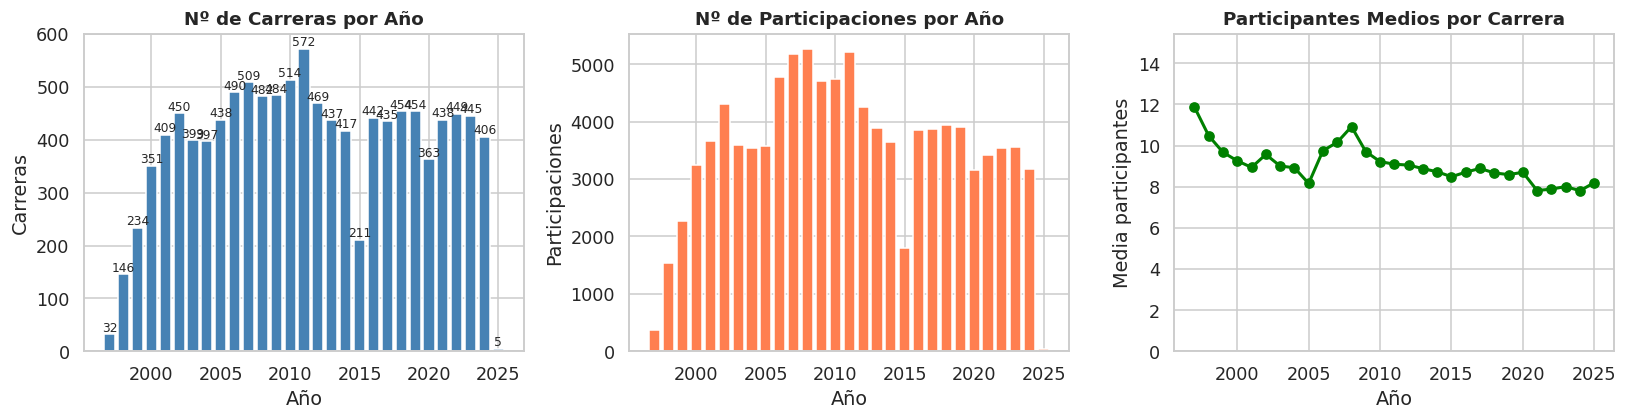

In [59]:
# ── Gráfico 1: Carreras y participaciones por año ─────────────────────────────
df['year'] = df['fecha'].dt.year
by_year = df.groupby('year').agg(
    n_carreras=('carrera_id','nunique'),
    n_part=('caballo_id','count')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1a. Carreras por año
axes[0].bar(by_year['year'], by_year['n_carreras'], color='steelblue', edgecolor='white')
axes[0].set_title('Nº de Carreras por Año')
axes[0].set_xlabel('Año'); axes[0].set_ylabel('Carreras')
for ax in [axes[0]]:
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

# 1b. Participaciones por año
axes[1].bar(by_year['year'], by_year['n_part'], color='coral', edgecolor='white')
axes[1].set_title('Nº de Participaciones por Año')
axes[1].set_xlabel('Año'); axes[1].set_ylabel('Participaciones')

# 1c. Media participantes por carrera por año
field_size = df.groupby(['year','carrera_id']).size().reset_index(name='field')
avg_field_yr = field_size.groupby('year')['field'].mean()
axes[2].plot(avg_field_yr.index, avg_field_yr.values, marker='o', color='green', linewidth=2)
axes[2].set_title('Participantes Medios por Carrera')
axes[2].set_xlabel('Año'); axes[2].set_ylabel('Media participantes')
axes[2].set_ylim(0, avg_field_yr.max() * 1.3)

plt.tight_layout()
plt.savefig(ROOT / 'docs' / 'eda_fig1_temporal.png', bbox_inches='tight', dpi=110)
plt.show()

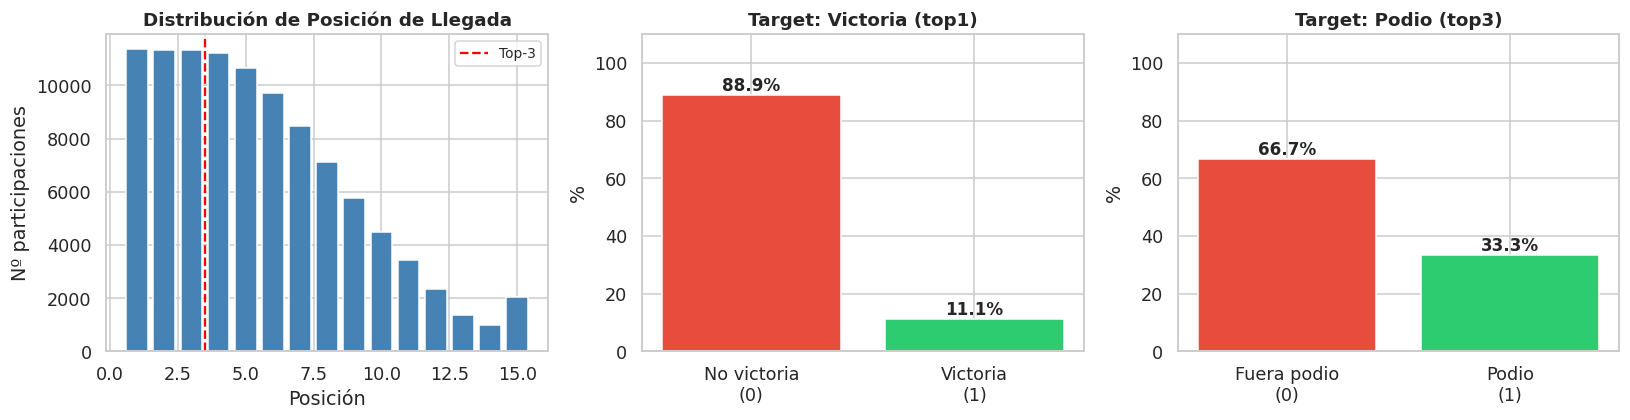

In [60]:
# ── Gráfico 2: Distribución de posiciones y targets ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 2a. Distribución posición de llegada (1-15)
pos_valid = df[df['target_pos'] > 0]['target_pos'].clip(upper=15)
pos_counts = pos_valid.value_counts().sort_index()
axes[0].bar(pos_counts.index, pos_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Posición de Llegada')
axes[0].set_xlabel('Posición'); axes[0].set_ylabel('Nº participaciones')
axes[0].axvline(3.5, color='red', linestyle='--', linewidth=1.5, label='Top-3')
axes[0].legend(fontsize=9)

# 2b. Target top1 (victoria)
top1_pct = df['target_top1'].value_counts(normalize=True) * 100
axes[1].bar(['No victoria\n(0)', 'Victoria\n(1)'], top1_pct.sort_index().values,
            color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[1].set_title('Target: Victoria (top1)')
axes[1].set_ylabel('%'); axes[1].set_ylim(0, 110)
for i, v in enumerate(top1_pct.sort_index().values):
    axes[1].text(i, v + 1.5, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

# 2c. Target top3 (podio)
top3_pct = df['target_top3'].value_counts(normalize=True) * 100
axes[2].bar(['Fuera podio\n(0)', 'Podio\n(1)'], top3_pct.sort_index().values,
            color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[2].set_title('Target: Podio (top3)')
axes[2].set_ylabel('%'); axes[2].set_ylim(0, 110)
for i, v in enumerate(top3_pct.sort_index().values):
    axes[2].text(i, v + 1.5, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(ROOT / 'docs' / 'eda_fig2_targets.png', bbox_inches='tight', dpi=110)
plt.show()

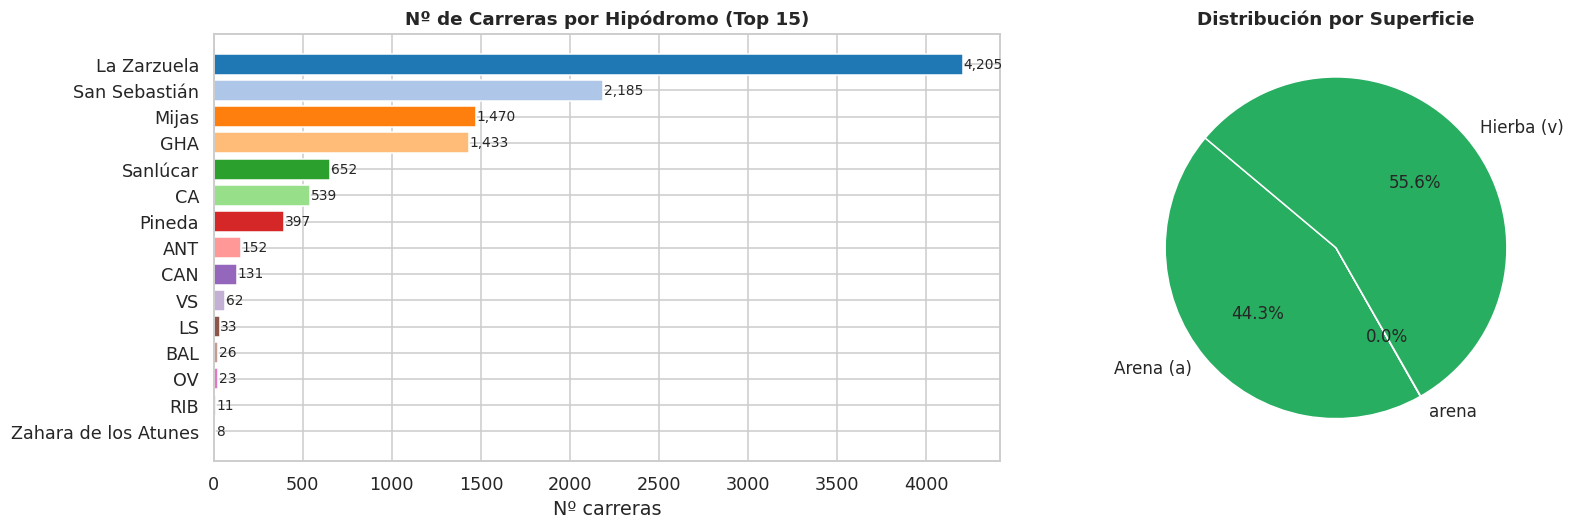

In [61]:
# ── Gráfico 3: Carreras por hipódromo y superficie ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 3a. Carreras por hipódromo (top 15, por número de participaciones)
hipo_counts = df.groupby('hipodromo')['carrera_id'].nunique().sort_values(ascending=False).head(15)
colors_h = plt.cm.tab20.colors[:len(hipo_counts)]
bars = axes[0].barh(hipo_counts.index[::-1], hipo_counts.values[::-1], color=colors_h[::-1])
axes[0].set_title('Nº de Carreras por Hipódromo (Top 15)')
axes[0].set_xlabel('Nº carreras')
for bar, val in zip(bars, hipo_counts.values[::-1]):
    axes[0].text(val + 5, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)

# 3b. Carreras por superficie (v=hierba, a=arena)
surf_map = {'v': 'Hierba (v)', 'a': 'Arena (a)'}
surf = df.groupby('pista')['carrera_id'].nunique()
surf.index = [surf_map.get(i, i) for i in surf.index]
wedge, texts, pcts = axes[1].pie(surf.values, labels=surf.index, autopct='%1.1f%%',
                                  colors=['#27ae60','#f39c12'], startangle=140,
                                  textprops={'fontsize':11})
axes[1].set_title('Distribución por Superficie')

plt.tight_layout()
plt.savefig(ROOT / 'docs' / 'eda_fig3_hipo_surface.png', bbox_inches='tight', dpi=110)
plt.show()

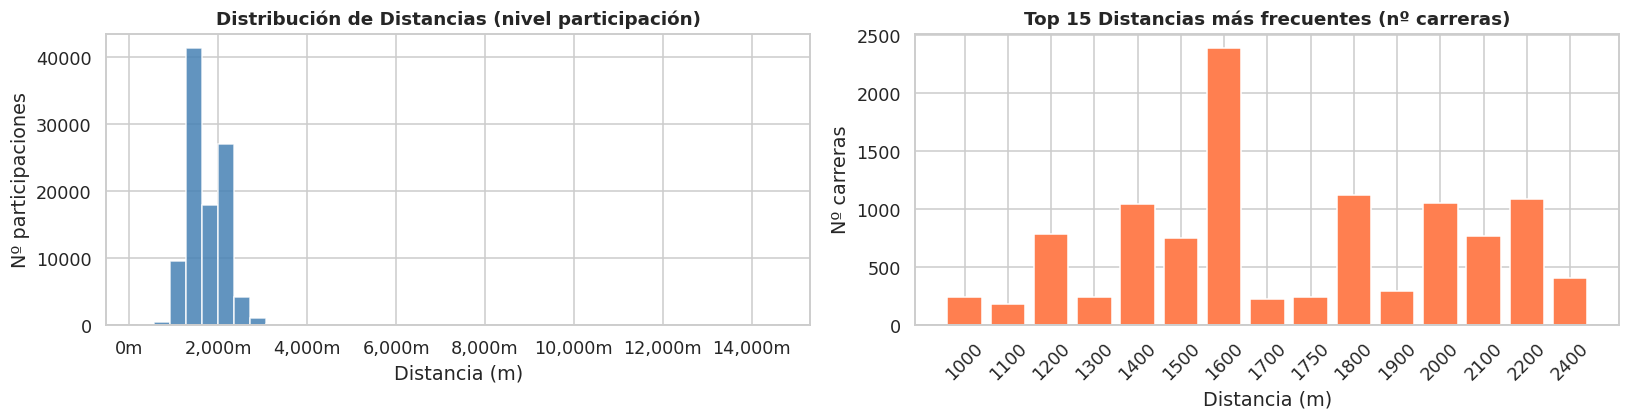

In [62]:
# ── Gráfico 4: Distribución de distancias ─────────────────────────────────────
dist_valid = df['distancia_m'].dropna()
dist_uniq  = df.groupby('carrera_id')['distancia_m'].first().dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# 4a. Histograma de distancias (nivel participación)
axes[0].hist(dist_valid, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribución de Distancias (nivel participación)')
axes[0].set_xlabel('Distancia (m)'); axes[0].set_ylabel('Nº participaciones')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}m'))

# 4b. Top 15 distancias por número de carreras únicas
top_dist = dist_uniq.value_counts().head(15).sort_index()
axes[1].bar([str(int(d)) for d in top_dist.index], top_dist.values,
            color='coral', edgecolor='white')
axes[1].set_title('Top 15 Distancias más frecuentes (nº carreras)')
axes[1].set_xlabel('Distancia (m)'); axes[1].set_ylabel('Nº carreras')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(ROOT / 'docs' / 'eda_fig4_distancias.png', bbox_inches='tight', dpi=110)
plt.show()

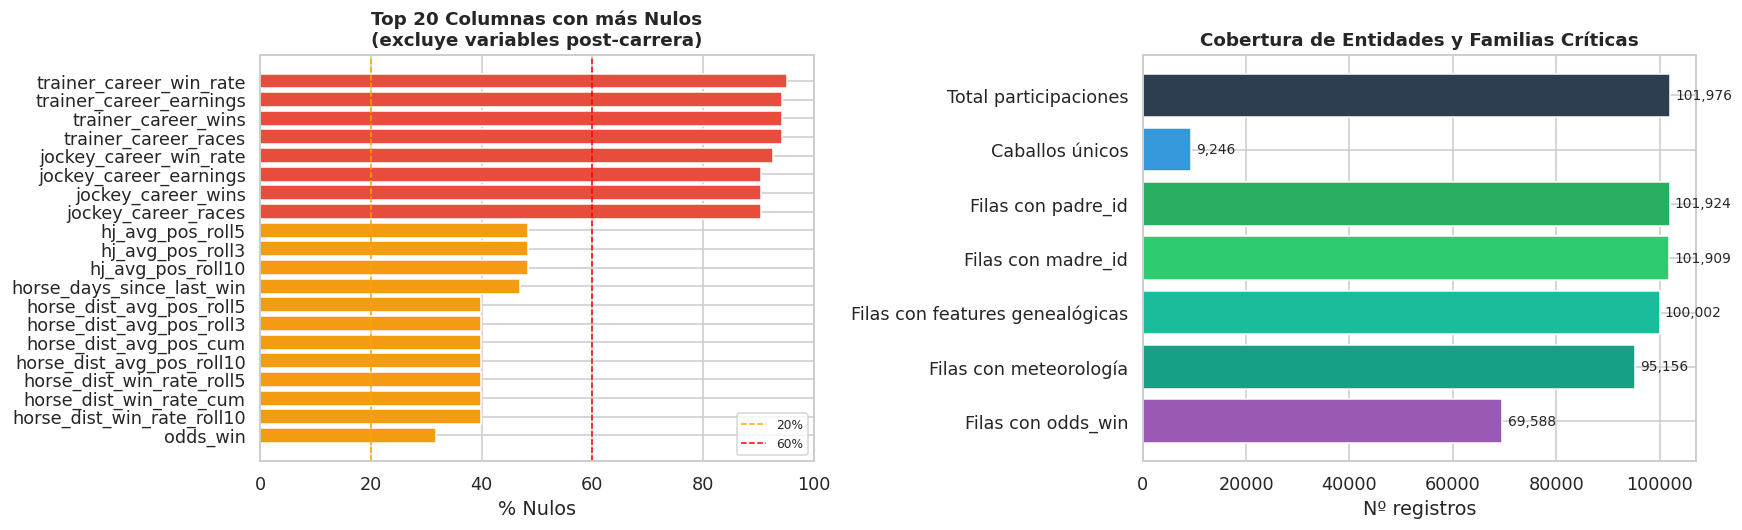

Cobertura padre_id: 99.949%
Cobertura madre_id: 99.934%
Cobertura features genealógicas sire: 98.064%
Cobertura meteorológica global: 93.312%


In [52]:
# ── Gráfico 5: nulos y cobertura de entidades críticas ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 5a. % nulos medios por dataset final
audit_cols = [c for c in df.columns if c not in ['pos', 'distancia_al_anterior']]
null_pct = (df[audit_cols].isnull().sum() / len(df) * 100).sort_values(ascending=False)
top_null = null_pct[null_pct > 5].head(20)
axes[0].barh(top_null.index[::-1], top_null.values[::-1],
             color=[('#e74c3c' if v > 60 else ('#f39c12' if v > 20 else '#3498db'))
                    for v in top_null.values[::-1]])
axes[0].set_title('Top 20 Columnas con más Nulos\n(excluye variables post-carrera)')
axes[0].set_xlabel('% Nulos')
axes[0].axvline(20, color='orange', linestyle='--', linewidth=1, label='20%')
axes[0].axvline(60, color='red', linestyle='--', linewidth=1, label='60%')
axes[0].legend(fontsize=8)

# 5b. Cobertura de IDs y familias críticas dentro del parquet final
n_total = len(df)
n_caballos_v5   = df['caballo_id'].nunique() if 'caballo_id' in df.columns else 0
n_padre_notnull  = df['padre_id'].notna().sum() if 'padre_id' in df.columns else 0
n_madre_notnull  = df['madre_id'].notna().sum() if 'madre_id' in df.columns else 0
n_gene_feat      = df['sire_offspring_races'].notna().sum() if 'sire_offspring_races' in df.columns else 0
n_weather        = df['weather_temp_max'].notna().sum() if 'weather_temp_max' in df.columns else 0
n_odds_notnull   = df['odds_win'].notna().sum() if 'odds_win' in df.columns else 0

coverage_data = {
    'Total participaciones': n_total,
    'Caballos únicos': n_caballos_v5,
    'Filas con padre_id': n_padre_notnull,
    'Filas con madre_id': n_madre_notnull,
    'Filas con features genealógicas': n_gene_feat,
    'Filas con meteorología': n_weather,
    'Filas con odds_win': n_odds_notnull,
}
colors = ['#2c3e50', '#3498db', '#27ae60', '#2ecc71', '#1abc9c', '#16a085', '#9b59b6']
axes[1].barh(list(coverage_data.keys())[::-1], list(coverage_data.values())[::-1], color=colors[::-1])
axes[1].set_title('Cobertura de Entidades y Familias Críticas')
axes[1].set_xlabel('Nº registros')
for i, v in enumerate(list(coverage_data.values())[::-1]):
    axes[1].text(v + max(coverage_data.values())*0.01, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print('Cobertura padre_id:', f"{100*n_padre_notnull/n_total:.3f}%")
print('Cobertura madre_id:', f"{100*n_madre_notnull/n_total:.3f}%")
if 'sire_offspring_races' in df.columns:
    print('Cobertura features genealógicas sire:', f"{100*df['sire_offspring_races'].notna().mean():.3f}%")
if 'weather_temp_max' in df.columns:
    print('Cobertura meteorológica global:', f"{100*df['weather_temp_max'].notna().mean():.3f}%")

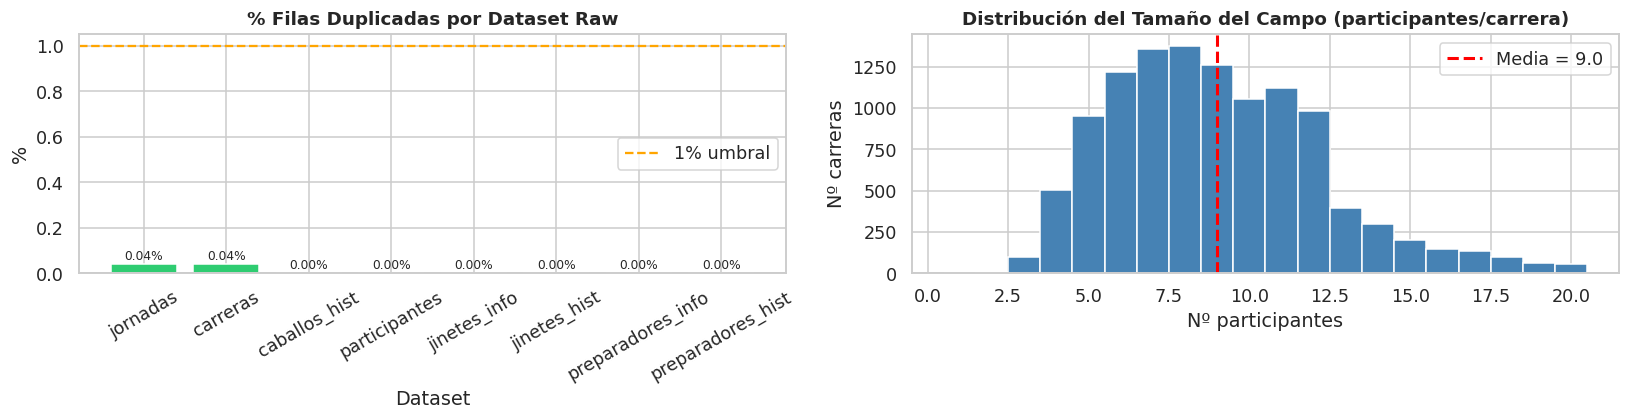

In [53]:
# ── Gráfico 6: Distribución de duplicados en raw datasets ────────────────────
dup_data = {}
for name, ddf in raw.items():
    if len(ddf) > 0:
        dup_data[name] = round(100 * ddf.duplicated().sum() / len(ddf), 2)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# 6a. % duplicados
sorted_dups = dict(sorted(dup_data.items(), key=lambda x: x[1], reverse=True))
bar_colors2 = ['#e74c3c' if v > 1 else '#2ecc71' for v in sorted_dups.values()]
axes[0].bar(list(sorted_dups.keys()), list(sorted_dups.values()), color=bar_colors2, edgecolor='white')
axes[0].set_title('% Filas Duplicadas por Dataset Raw')
axes[0].set_ylabel('%'); axes[0].set_xlabel('Dataset')
axes[0].tick_params(axis='x', rotation=30)
axes[0].axhline(1, color='orange', linestyle='--', linewidth=1.5, label='1% umbral')
axes[0].legend()
for i, (k, v) in enumerate(sorted_dups.items()):
    axes[0].text(i, v + 0.02, f'{v:.2f}%', ha='center', fontsize=8)

# 6b. Distribución tamaño del campo (nº participantes por carrera)
field_sizes = df.groupby('carrera_id').size()
axes[1].hist(field_sizes, bins=range(1, field_sizes.max() + 2),
             color='steelblue', edgecolor='white', align='left')
axes[1].axvline(field_sizes.mean(), color='red', linestyle='--',
                linewidth=2, label=f'Media = {field_sizes.mean():.1f}')
axes[1].set_title('Distribución del Tamaño del Campo (participantes/carrera)')
axes[1].set_xlabel('Nº participantes'); axes[1].set_ylabel('Nº carreras')
axes[1].legend()

plt.tight_layout()
plt.savefig(ROOT / 'docs' / 'eda_fig6_dups_fieldsize.png', bbox_inches='tight', dpi=110)
plt.show()

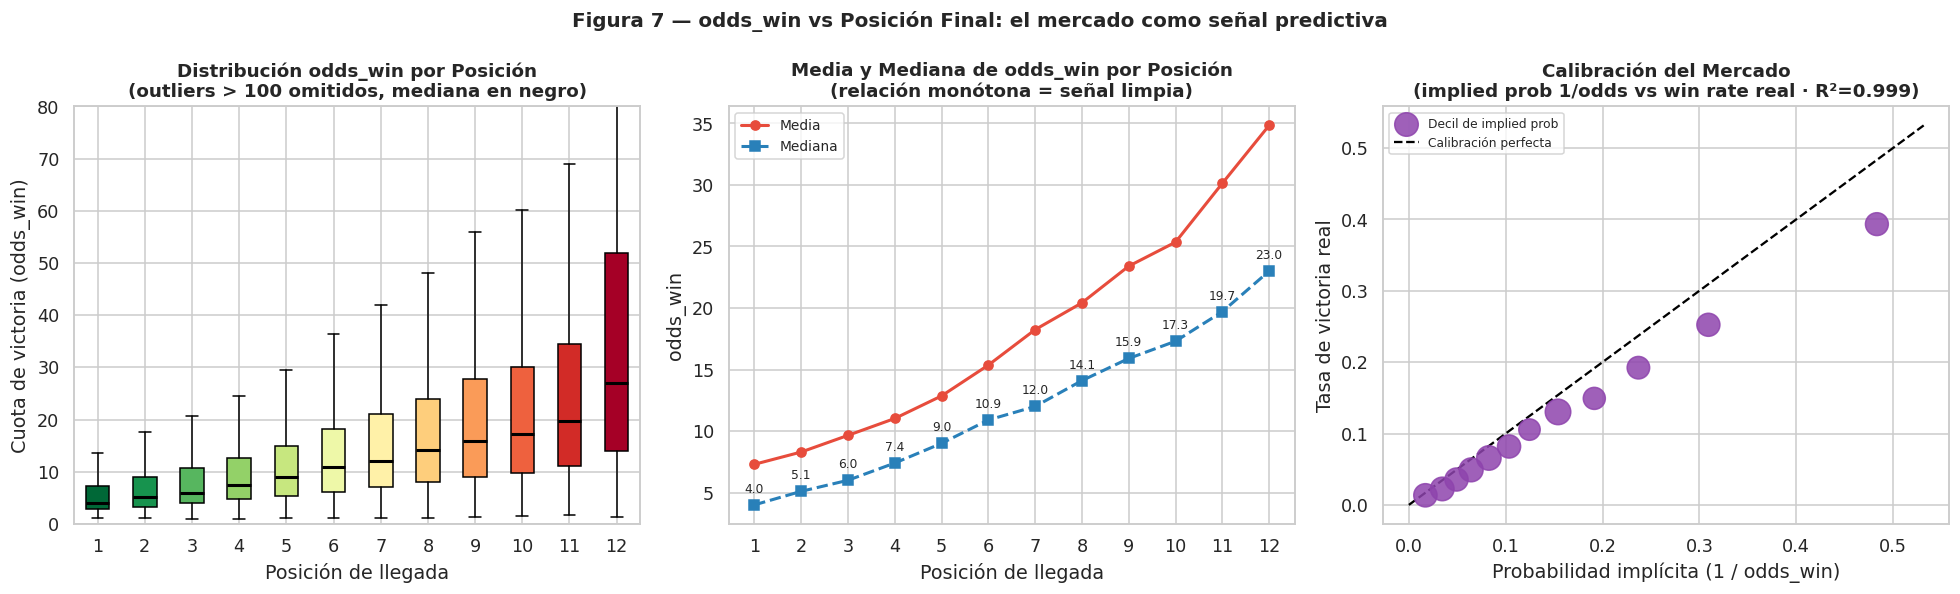


📊 ODDS_WIN — Resumen por posición (posiciones 1–5 vs 8–12):
  Ganadores (pos 1)   — mediana odds: 4.0
  Top-5 (pos 1–5)     — mediana odds: 6.0  (n=37,654)
  Cola (pos 8–12)     — mediana odds: 18.0  (n=19,433)
  Correlación Pearson odds_win → target_top1: -0.0962
  R² calibración (implied prob vs win rate): 0.999

  ✅ Señal clara: cuotas bajas → posiciones más altas. El mercado es un predictor robusto.


In [54]:
# ══════════════════════════════════════════════════════════════════════════════
# EDA — ODDS_WIN VS POSICIÓN FINAL
# Figura 7: Relación entre la cuota de mercado y el resultado real en carrera
# • Hipótesis: cuotas bajas (caballo favorito) → posiciones más altas
# • Relevancia científica: calibración del mercado como prior predictivo
# ══════════════════════════════════════════════════════════════════════════════

df_o = df[df['odds_win'].notna() & (df['odds_win'] > 0) & (df['target_pos'] > 0)].copy()
df_o['implied_prob'] = 1.0 / df_o['odds_win']
df_o['pos_clip'] = df_o['target_pos'].clip(upper=12)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle('Figura 7 — odds_win vs Posición Final: el mercado como señal predictiva',
             fontsize=13, fontweight='bold')

# ── 7a: Boxplot odds por posición (1–12) ──────────────────────────────────────
pos_groups = [df_o[df_o['pos_clip'] == p]['odds_win'].clip(upper=100) for p in range(1, 13)]
bp = axes[0].boxplot(pos_groups, labels=list(range(1, 13)),
                     patch_artist=True, notch=False, showfliers=False,
                     medianprops=dict(color='black', linewidth=2))
cmap = plt.cm.RdYlGn_r
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(cmap(i / 11))
axes[0].set_title('Distribución odds_win por Posición\n(outliers > 100 omitidos, mediana en negro)')
axes[0].set_xlabel('Posición de llegada')
axes[0].set_ylabel('Cuota de victoria (odds_win)')
axes[0].set_ylim(0, 80)

# ── 7b: Media y mediana de odds por posición ──────────────────────────────────
stats_by_pos = (df_o[df_o['target_pos'] <= 12]
                .groupby('target_pos')['odds_win']
                .agg(['mean', 'median', 'count'])
                .reset_index())
x = stats_by_pos['target_pos']
axes[1].plot(x, stats_by_pos['mean'],   'o-', color='#e74c3c', linewidth=2, label='Media')
axes[1].plot(x, stats_by_pos['median'], 's--', color='#2980b9', linewidth=2, label='Mediana')
for _, row in stats_by_pos.iterrows():
    axes[1].annotate(f'{row["median"]:.1f}',
                     (row['target_pos'], row['median']),
                     textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
axes[1].set_title('Media y Mediana de odds_win por Posición\n(relación monótona = señal limpia)')
axes[1].set_xlabel('Posición de llegada')
axes[1].set_ylabel('odds_win')
axes[1].legend(fontsize=9)
axes[1].set_xticks(range(1, 13))

# ── 7c: Tasa de victorias real vs probabilidad implícita (calibración) ────────
df_o['odds_bin_label'] = pd.qcut(df_o['implied_prob'], q=12, duplicates='drop')
calib2 = (df_o.groupby('odds_bin_label', observed=True)
          .agg(implied=('implied_prob', 'mean'),
               actual=('target_top1', 'mean'),
               n=('target_top1', 'count'))
          .dropna())
axes[2].scatter(calib2['implied'], calib2['actual'],
                s=calib2['n'] / 25, color='#8e44ad', alpha=0.85, zorder=3,
                label='Decil de implied prob')
max_v = max(calib2['implied'].max(), calib2['actual'].max()) * 1.1
axes[2].plot([0, max_v], [0, max_v], 'k--', linewidth=1.5, label='Calibración perfecta')
# R²
r2 = float(pd.DataFrame({'x': calib2['implied'], 'y': calib2['actual']}).corr().iloc[0, 1] ** 2)
axes[2].set_title(f'Calibración del Mercado\n(implied prob 1/odds vs win rate real · R²={r2:.3f})')
axes[2].set_xlabel('Probabilidad implícita (1 / odds_win)')
axes[2].set_ylabel('Tasa de victoria real')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(ROOT / 'docs' / 'eda_fig7_odds_vs_position.png', bbox_inches='tight', dpi=110)
plt.show()

# ── Resumen estadístico ────────────────────────────────────────────────────────
print('\n📊 ODDS_WIN — Resumen por posición (posiciones 1–5 vs 8–12):')
top5  = df_o[df_o['target_pos'] <= 5]['odds_win']
bot5  = df_o[df_o['target_pos'] >= 8]['odds_win']
print(f'  Ganadores (pos 1)   — mediana odds: {df_o[df_o["target_pos"]==1]["odds_win"].median():.1f}')
print(f'  Top-5 (pos 1–5)     — mediana odds: {top5.median():.1f}  (n={len(top5):,})')
print(f'  Cola (pos 8–12)     — mediana odds: {bot5.median():.1f}  (n={len(bot5):,})')
print(f'  Correlación Pearson odds_win → target_top1: {df_o["odds_win"].corr(df_o["target_top1"]):.4f}')
print(f'  R² calibración (implied prob vs win rate): {r2:.3f}')
print(f'\n  ✅ Señal clara: cuotas bajas → posiciones más altas. El mercado es un predictor robusto.')

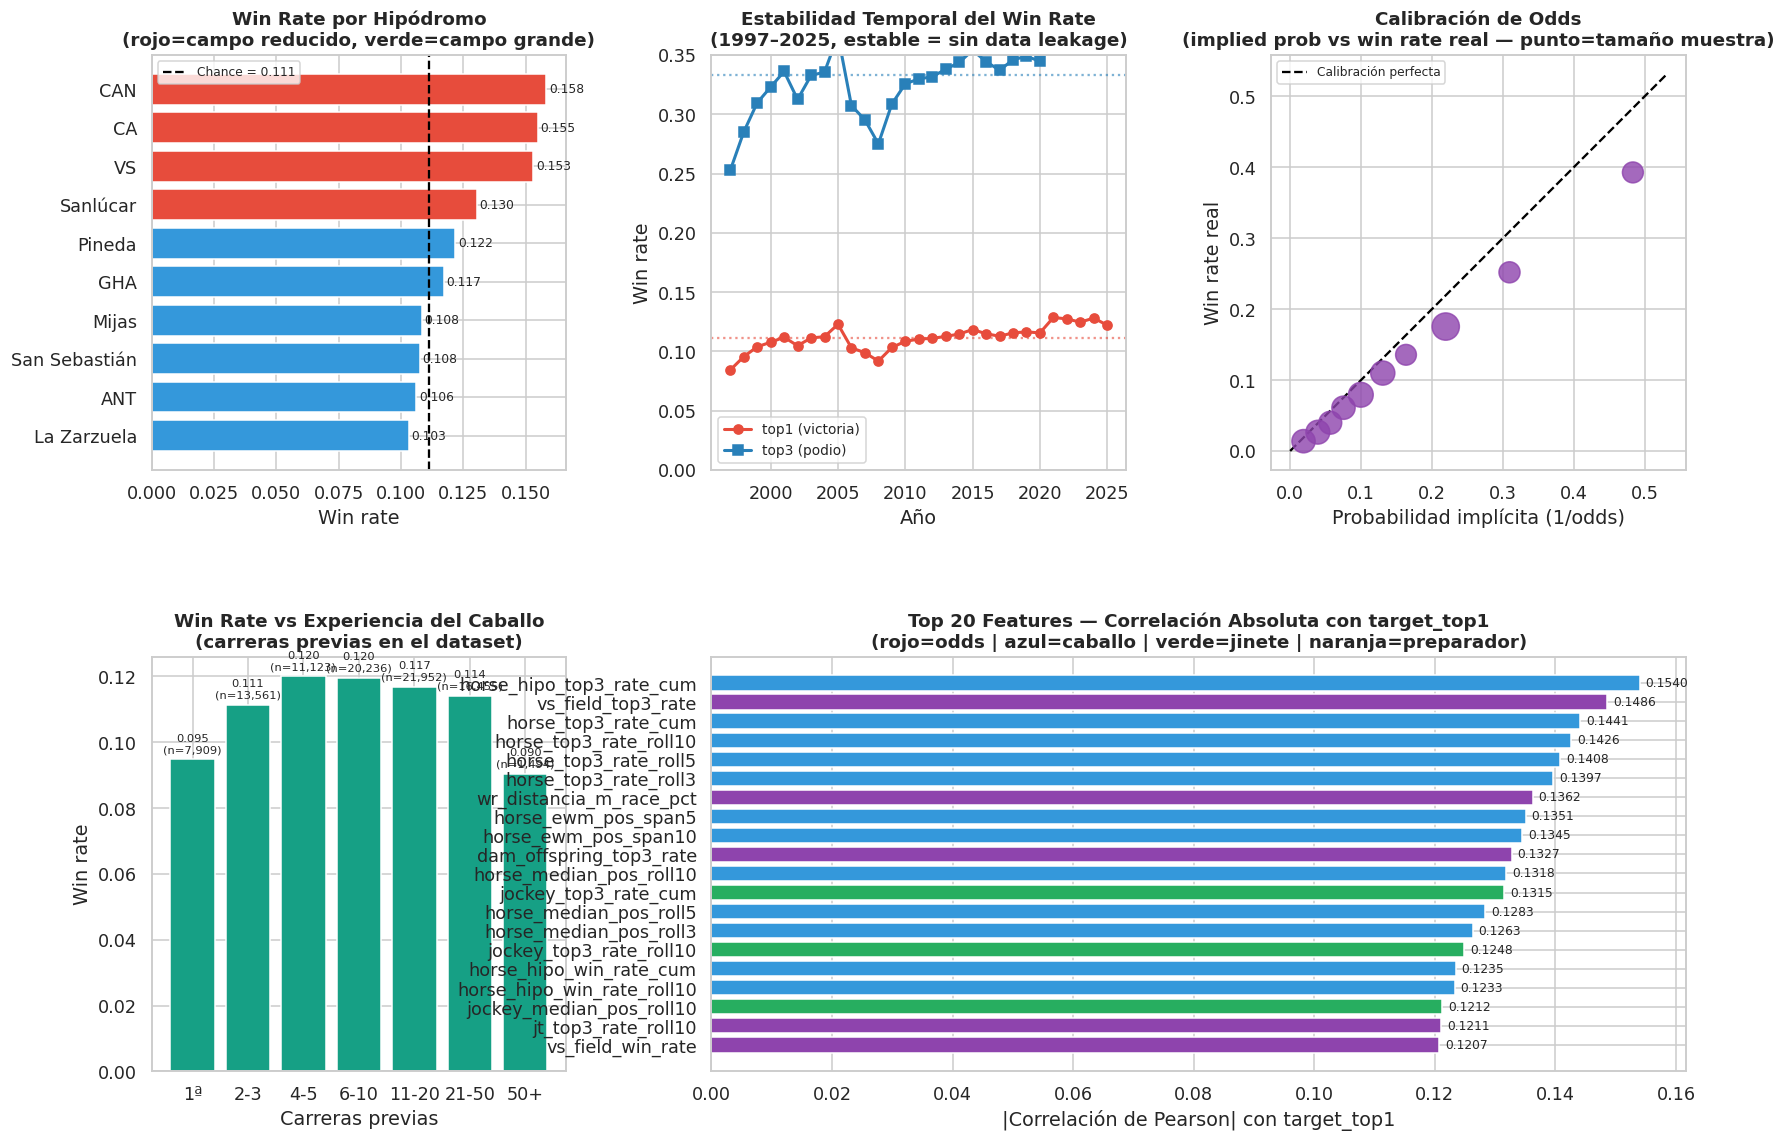


📊 RESUMEN DE SEÑAL PREDICTIVA:
  Chance baseline (1/campo):           0.1111
  Top feature (|corr| con target_top1): horse_hipo_top3_rate_cum = 0.1540
  Calibración odds: R² mercado/real:   0.999
  Estabilidad win_rate (CV 1997-2024): 0.096  (< 0.10 = estable)


In [63]:
# ══════════════════════════════════════════════════════════════════════════════
# EDA — SEÑAL PREDICTIVA: ¿Cuánto predicen las features el resultado?
# KPI 1: win rate por hipódromo  |  KPI 2: estabilidad temporal del win rate
# KPI 3: calibración de las odds (¿es eficiente el mercado?)
# ══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(18, 12))
gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

# ── KPI 1: Win rate por hipódromo (top 12) ────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
hipo_wr = (df.groupby('hipodromo')
             .agg(win_rate=('target_top1','mean'), n=('target_top1','count'))
             .query('n >= 300')
             .sort_values('win_rate', ascending=False)
             .head(12))
random_wr = 1 / df.groupby('carrera_id').size().mean()
colors_wr = ['#e74c3c' if v > random_wr*1.15 else ('#27ae60' if v < random_wr*0.85 else '#3498db')
             for v in hipo_wr['win_rate']]
bars = ax1.barh(hipo_wr.index[::-1], hipo_wr['win_rate'].values[::-1], color=colors_wr[::-1])
ax1.axvline(random_wr, color='black', linestyle='--', linewidth=1.5,
            label=f'Chance = {random_wr:.3f}')
ax1.set_title('Win Rate por Hipódromo\n(rojo=campo reducido, verde=campo grande)')
ax1.set_xlabel('Win rate'); ax1.legend(fontsize=8)
for bar, val in zip(bars, hipo_wr['win_rate'].values[::-1]):
    ax1.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=8)

# ── KPI 2: Win rate por año (estabilidad temporal) ───────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
df_mod = df.copy()
yr_wr = df_mod.groupby('year').agg(
    wr_top1=('target_top1','mean'),
    wr_top3=('target_top3','mean'),
    n=('target_top1','count')
)
ax2.plot(yr_wr.index, yr_wr['wr_top1'], 'o-', color='#e74c3c', label='top1 (victoria)', linewidth=2)
ax2.plot(yr_wr.index, yr_wr['wr_top3'], 's-', color='#2980b9', label='top3 (podio)',   linewidth=2)
ax2.axhline(yr_wr['wr_top1'].mean(), color='#e74c3c', linestyle=':', alpha=0.6)
ax2.axhline(yr_wr['wr_top3'].mean(), color='#2980b9', linestyle=':', alpha=0.6)
ax2.set_title('Estabilidad Temporal del Win Rate\n(1997–2025, estable = sin data leakage)')
ax2.set_xlabel('Año'); ax2.set_ylabel('Win rate')
ax2.legend(fontsize=9); ax2.set_ylim(0, 0.35)

# ── KPI 3: Calibración de odds (¿mercado eficiente?) ─────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
df_odds = df[df['odds_win'].notna() & (df['odds_win'] > 0)].copy()
# Implied probability = 1/odds
df_odds['implied_prob'] = 1 / df_odds['odds_win']
df_odds['odds_bin'] = pd.qcut(df_odds['implied_prob'], q=10, duplicates='drop')
calib = df_odds.groupby('odds_bin', observed=True).agg(
    implied=('implied_prob','mean'),
    actual=('target_top1','mean'),
    n=('target_top1','count')
).dropna()
ax3.scatter(calib['implied'], calib['actual'], s=calib['n']/30,
            color='#8e44ad', alpha=0.8, zorder=3)
max_val = max(calib['implied'].max(), calib['actual'].max()) * 1.1
ax3.plot([0, max_val], [0, max_val], 'k--', linewidth=1.5, label='Calibración perfecta')
ax3.set_title('Calibración de Odds\n(implied prob vs win rate real — punto=tamaño muestra)')
ax3.set_xlabel('Probabilidad implícita (1/odds)'); ax3.set_ylabel('Win rate real')
ax3.legend(fontsize=8)

# ── KPI 4: Curva de experiencia (¿ganan más los caballos veteranos?) ──────────
ax4 = fig.add_subplot(gs[1, 0])
df_exp = df[df['horse_n_prev_races'].notna()].copy()
df_exp['exp_bin'] = pd.cut(df_exp['horse_n_prev_races'],
                            bins=[0,1,3,5,10,20,50,500],
                            labels=['1ª','2-3','4-5','6-10','11-20','21-50','50+'])
exp_wr = df_exp.groupby('exp_bin', observed=True).agg(
    wr=('target_top1','mean'), n=('target_top1','count')).dropna()
ax4.bar(exp_wr.index.astype(str), exp_wr['wr'], color='#16a085', edgecolor='white')
ax4.set_title('Win Rate vs Experiencia del Caballo\n(carreras previas en el dataset)')
ax4.set_xlabel('Carreras previas'); ax4.set_ylabel('Win rate')
for i, (idx, row) in enumerate(exp_wr.iterrows()):
    ax4.text(i, row['wr'] + 0.002, f'{row["wr"]:.3f}\n(n={row["n"]:,})',
             ha='center', fontsize=7.5)

# ── KPI 5: Top 15 features por correlación absoluta con target ───────────────
ax5 = fig.add_subplot(gs[1, 1:])
feat_candidates = [c for c in df.columns
                   if c not in ('target_top1','target_top3','target_pos',
                                'carrera_id','caballo_id','jinete_id','preparador_id',
                                'jornada_id','fecha','nombre','carrera_nombre',
                                'hipodromo','pista','condiciones','padre_id','madre_id',
                                'year')
                   and df[c].dtype in ('float64','int64','float32','int32')]
corr_target = (df[feat_candidates + ['target_top1']]
               .corr()['target_top1']
               .drop('target_top1')
               .dropna()
               .abs()
               .sort_values(ascending=False)
               .head(20))
colors_c = ['#e74c3c' if 'odds' in c else
            ('#3498db' if 'horse' in c else
             ('#27ae60' if 'jockey' in c else
              ('#f39c12' if 'trainer' in c else '#8e44ad')))
            for c in corr_target.index]
ax5.barh(corr_target.index[::-1], corr_target.values[::-1], color=colors_c[::-1])
ax5.set_title('Top 20 Features — Correlación Absoluta con target_top1\n'
              '(rojo=odds | azul=caballo | verde=jinete | naranja=preparador)')
ax5.set_xlabel('|Correlación de Pearson| con target_top1')
for i, val in enumerate(corr_target.values[::-1]):
    ax5.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=8)

plt.savefig(ROOT / 'docs' / 'eda_fig7_predictive_signal.png', bbox_inches='tight', dpi=110)
plt.show()

print('\n📊 RESUMEN DE SEÑAL PREDICTIVA:')
print(f'  Chance baseline (1/campo):           {random_wr:.4f}')
print(f'  Top feature (|corr| con target_top1): {corr_target.index[0]} = {corr_target.values[0]:.4f}')
print(f'  Calibración odds: R² mercado/real:   {np.corrcoef(calib["implied"], calib["actual"])[0,1]**2:.3f}')
print(f'  Estabilidad win_rate (CV 1997-2024): {yr_wr["wr_top1"].std()/yr_wr["wr_top1"].mean():.3f}  (< 0.10 = estable)')

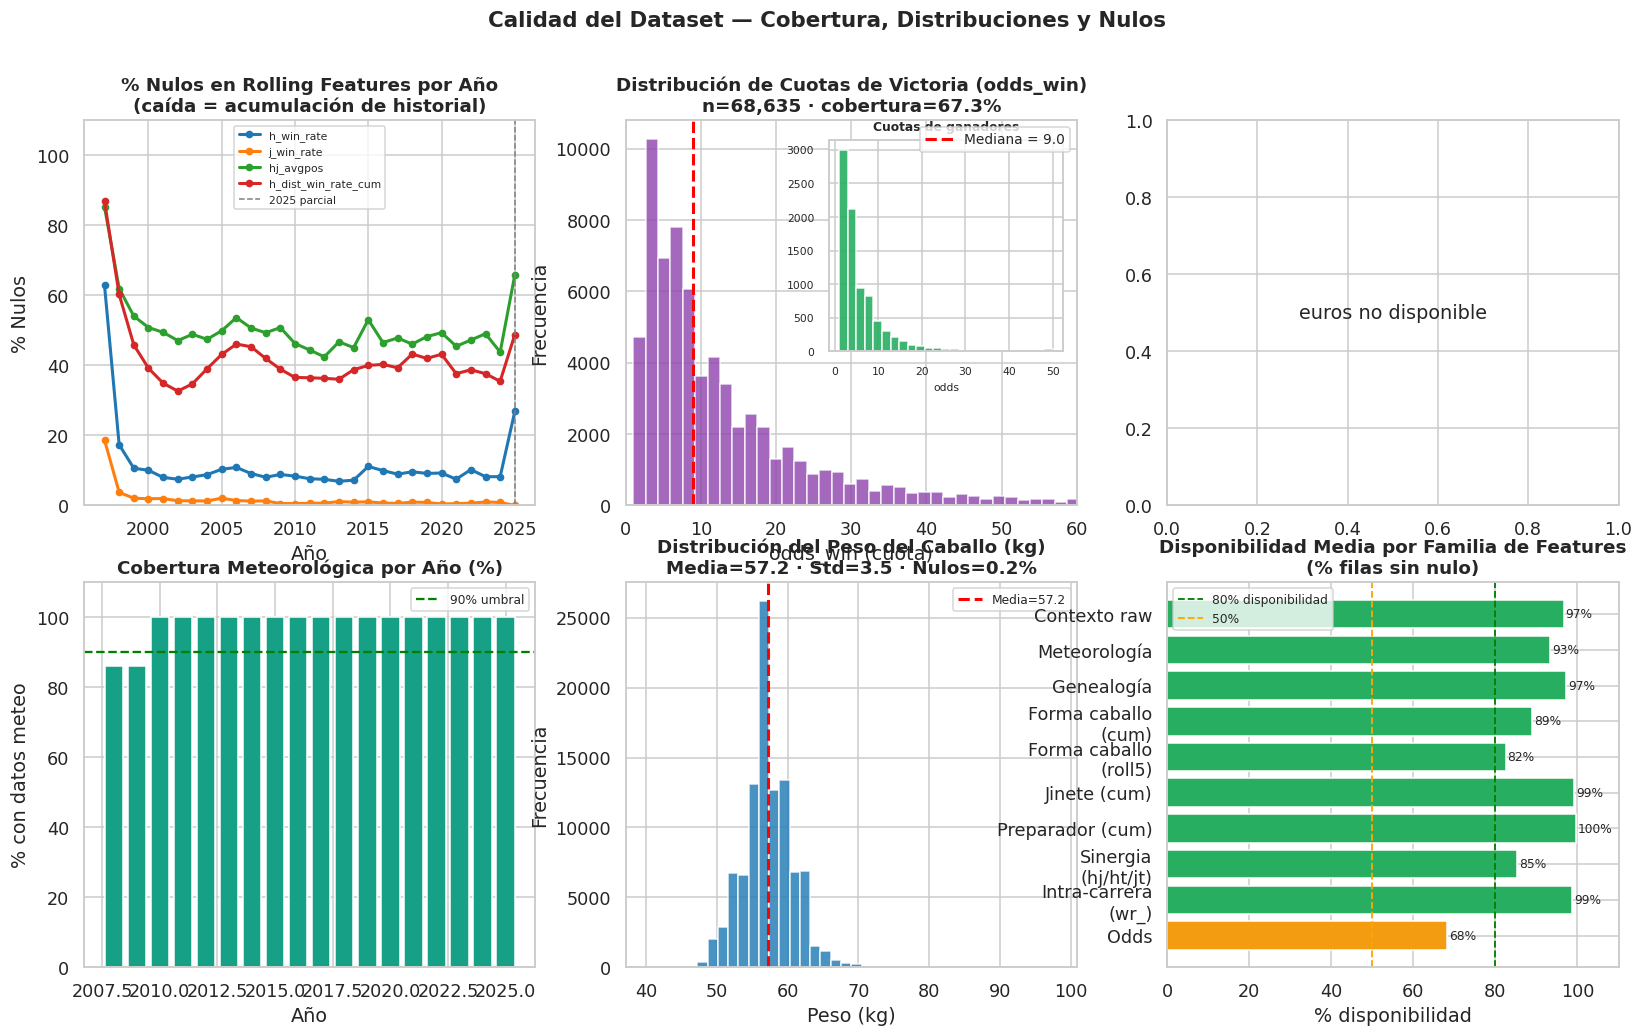

In [64]:
# ══════════════════════════════════════════════════════════════════════════════
# EDA — CALIDAD DEL DATASET: nulos en el tiempo + distribuciones de features clave
# KPI 6: evolución de nulos (historial previo y año 2025 parcial)
# KPI 7: distribución de odds (market shape)
# KPI 8: distribución peso / prize money (skewness)
# KPI 9: cobertura meteorológica por año
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Calidad del Dataset — Cobertura, Distribuciones y Nulos', fontsize=14, fontweight='bold')

# ── KPI 6: % nulos de rolling features por año ─────────────────────────────
df_mod = df.copy()
roll_cols = ['horse_win_rate_roll5', 'jockey_win_rate_roll5',
             'hj_avg_pos_roll5', 'horse_dist_win_rate_cum']
roll_cols = [c for c in roll_cols if c in df_mod.columns]
null_by_yr = df_mod.groupby('year')[roll_cols].apply(lambda g: g.isnull().mean() * 100)
for col in roll_cols:
    lbl = col.replace('_roll5','').replace('horse_','h_').replace('jockey_','j_').replace('hj_avg_pos','hj_avgpos')
    axes[0,0].plot(null_by_yr.index, null_by_yr[col], marker='o', linewidth=2, label=lbl, markersize=4)
axes[0,0].axvline(2025, color='grey', linestyle='--', linewidth=1, label='2025 parcial')
axes[0,0].set_title('% Nulos en Rolling Features por Año\n(caída = acumulación de historial)')
axes[0,0].set_xlabel('Año'); axes[0,0].set_ylabel('% Nulos')
axes[0,0].legend(fontsize=7); axes[0,0].set_ylim(0, 110)

# ── KPI 7: Distribución de odds (cuotas de victoria) ─────────────────────────
df_odds2 = df[(df['odds_win'].notna()) & (df['odds_win'] > 0) & (df['odds_win'] < 100)].copy()
axes[0,1].hist(df_odds2['odds_win'], bins=60, color='#8e44ad', edgecolor='white', alpha=0.8)
axes[0,1].axvline(df_odds2['odds_win'].median(), color='red', linestyle='--',
                   linewidth=2, label=f'Mediana = {df_odds2["odds_win"].median():.1f}')
axes[0,1].set_title(f'Distribución de Cuotas de Victoria (odds_win)\nn={len(df_odds2):,} · cobertura={100*len(df_odds2)/len(df):.1f}%')
axes[0,1].set_xlabel('odds_win (cuota)'); axes[0,1].set_ylabel('Frecuencia')
axes[0,1].legend(fontsize=9)
axes[0,1].set_xlim(0, 60)

# Inset: ganadores por bucket de odds
ax_ins = axes[0,1].inset_axes([0.45, 0.4, 0.52, 0.55])
winners = df_odds2[df_odds2['target_top1'] == 1]['odds_win'].clip(upper=50)
ax_ins.hist(winners, bins=25, color='#27ae60', edgecolor='white', alpha=0.9)
ax_ins.set_title('Cuotas de ganadores', fontsize=8)
ax_ins.set_xlabel('odds', fontsize=7); ax_ins.tick_params(labelsize=7)

# ── KPI 8: Distribución de premio en euros (prize skewness) ──────────────────
if 'euros' in df.columns:
    prize = df[df['euros'] > 0]['euros'].dropna()
    axes[0,2].hist(prize.clip(upper=prize.quantile(0.99)), bins=50,
                   color='#f39c12', edgecolor='white', alpha=0.85)
    axes[0,2].set_title(f'Distribución Premio Carrera (euros)\nMedia={prize.mean():,.0f}€ · Mediana={prize.median():,.0f}€')
    axes[0,2].set_xlabel('Premio (€)'); axes[0,2].set_ylabel('Nº carreras')
    axes[0,2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}€'))
else:
    axes[0,2].text(0.5, 0.5, 'euros no disponible', ha='center', va='center', transform=axes[0,2].transAxes)

# ── KPI 9: Cobertura meteorológica por año ────────────────────────────────────
if 'weather_temp_max' in df.columns:
    df_wx = df[df['year'] >= 2008].copy()
    wx_cov = df_wx.groupby('year')['weather_temp_max'].apply(lambda x: 100*x.notna().sum()/len(x))
    axes[1,0].bar(wx_cov.index, wx_cov.values, color='#16a085', edgecolor='white')
    axes[1,0].axhline(90, color='green', linestyle='--', linewidth=1.5, label='90% umbral')
    axes[1,0].set_title('Cobertura Meteorológica por Año (%)')
    axes[1,0].set_xlabel('Año'); axes[1,0].set_ylabel('% con datos meteo')
    axes[1,0].set_ylim(0, 110); axes[1,0].legend(fontsize=8)

# ── KPI 10: Distribución del peso del caballo ─────────────────────────────────
if 'peso' in df.columns:
    peso_v = df['peso'].dropna()
    axes[1,1].hist(peso_v, bins=40, color='#2980b9', edgecolor='white', alpha=0.85)
    axes[1,1].axvline(peso_v.mean(), color='red', linestyle='--', linewidth=2,
                       label=f'Media={peso_v.mean():.1f}')
    axes[1,1].set_title(f'Distribución del Peso del Caballo (kg)\n'
                         f'Media={peso_v.mean():.1f} · Std={peso_v.std():.1f} · '
                         f'Nulos={100*df["peso"].isna().sum()/len(df):.1f}%')
    axes[1,1].set_xlabel('Peso (kg)'); axes[1,1].set_ylabel('Frecuencia')
    axes[1,1].legend(fontsize=8)

# ── KPI 11: Resumen de cobertura de todas las familias de features ─────────────
families = {
    'Contexto raw':     [c for c in ['fecha','hipodromo','distancia_m','pista','peso','casilla'] if c in df.columns],
    'Meteorología':     [c for c in df.columns if c.startswith('weather_') or c in ['temp_max','temp_min','precipitation','wind_speed_max']],
    'Genealogía':       [c for c in df.columns if c in ['padre_id','madre_id','criador_id'] or c.startswith(('sire_','dam_'))],
    'Forma caballo\n(cum)': [c for c in df.columns if 'horse_' in c and '_cum' in c],
    'Forma caballo\n(roll5)': [c for c in df.columns if 'horse_' in c and 'roll5' in c],
    'Jinete (cum)':     [c for c in df.columns if 'jockey_' in c and '_cum' in c],
    'Preparador (cum)': [c for c in df.columns if 'trainer_' in c and '_cum' in c],
    'Sinergia\n(hj/ht/jt)': [c for c in df.columns if c[:3] in ('hj_','ht_','jt_')],
    'Intra-carrera\n(wr_)': [c for c in df.columns if c.startswith('wr_')],
    'Odds': [c for c in df.columns if c in ('odds_win','dist_al_anterior')],
    'Meteorología': [c for c in df.columns if c.startswith('weather_')],
}
fam_names = list(families.keys())
fam_avail  = [100 * sum(df[c].notna().sum()/len(df) for c in cols)/max(len(cols),1)
              for cols in families.values()]
bar_colors_f = ['#27ae60' if v >= 80 else ('#f39c12' if v >= 50 else '#e74c3c')
                for v in fam_avail]
axes[1,2].barh(fam_names[::-1], fam_avail[::-1], color=bar_colors_f[::-1])
axes[1,2].axvline(80, color='green', linestyle='--', linewidth=1.2, label='80% disponibilidad')
axes[1,2].axvline(50, color='orange',linestyle='--', linewidth=1.2, label='50%')
axes[1,2].set_title('Disponibilidad Media por Familia de Features\n(% filas sin nulo)')
axes[1,2].set_xlabel('% disponibilidad'); axes[1,2].set_xlim(0, 110)
axes[1,2].legend(fontsize=8)
for i, v in enumerate(fam_avail[::-1]):
    axes[1,2].text(v + 0.5, i, f'{v:.0f}%', va='center', fontsize=8)

plt.savefig(ROOT / 'docs' / 'eda_fig8_quality_coverage.png', bbox_inches='tight', dpi=110)
plt.show()

In [57]:
# ══════════════════════════════════════════════════════════════════════════════
# EDA — KPI DASHBOARD FINAL: resumen ejecutivo del potencial del dataset
# ══════════════════════════════════════════════════════════════════════════════

# Calcular todos los KPIs
df_mod = df.copy()
df_odds_kpi = df_mod[df_mod['odds_win'].notna() & (df_mod['odds_win'] > 0)].copy()
df_odds_kpi['implied_prob'] = 1 / df_odds_kpi['odds_win']
df_odds_kpi['odds_bin'] = pd.qcut(df_odds_kpi['implied_prob'], q=8, duplicates='drop')
calib_kpi = df_odds_kpi.groupby('odds_bin', observed=True).agg(
    implied=('implied_prob','mean'), actual=('target_top1','mean')).dropna()

top_corr = None
feat_candidates2 = [c for c in df_mod.columns
                    if c not in ('target_top1','target_top3','target_pos',
                                 'carrera_id','caballo_id','jinete_id','preparador_id',
                                 'jornada_id','fecha','nombre','carrera_nombre',
                                 'hipodromo','pista','condiciones','padre_id','madre_id','criador_id','year',
                                 'pos','distancia_al_anterior','odds_win','dividendo_ganador')
                    and df_mod[c].dtype in ('float64','int64','float32','int32')]
top_corr = (df_mod[feat_candidates2 + ['target_top1']]
            .corr()['target_top1'].drop('target_top1')
            .dropna().abs().sort_values(ascending=False))

random_baseline = 1 / df_mod.groupby('carrera_id').size().mean()

kpis = {
    '01_filas_total'         : (f'{len(df):,}',              'Participaciones totales en el dataset'),
    '02_carreras_unicas'     : (f'{df["carrera_id"].nunique():,}', 'Carreras únicas'),
    '03_periodo'             : (f'{df["fecha"].min().year}–{df["fecha"].max().year}', 'Rango temporal (años)'),
    '04_features'            : (f'{df.shape[1]}',            'Features en dataset final'),
    '05_always_avail_feats'  : (f'{sum(df[c].isna().sum()==0 for c in feat_candidates2)}', 'Features siempre disponibles (0 nulos)'),
    '06_class_imbalance'     : (f'1:{1/random_baseline:.0f}', 'Ratio clase positiva/negativa (top1)'),
    '07_top_feature_corr'    : (f'{top_corr.index[0]} = {top_corr.values[0]:.4f}', 'Feature más predictiva (|Pearson| vs top1)'),
    '08_odds_r2_calibration' : (f'{np.corrcoef(calib_kpi["implied"], calib_kpi["actual"])[0,1]**2:.3f}', 'R² calibración odds (1.0 = mercado perfecto)'),
    '09_odds_coverage'       : (f'{100*df["odds_win"].notna().sum()/len(df):.1f}%', 'Cobertura de odds_win'),
    '10_weather_coverage'    : (f'{100*df["weather_temp_max"].notna().sum()/len(df):.1f}%', 'Cobertura meteorológica'),
    '11_win_rate_cv'         : (f'{df_mod.groupby("year")["target_top1"].mean().std()/df_mod.groupby("year")["target_top1"].mean().mean():.3f}', 'CV win rate 1997-2025 (< 0.1 = muy estable)'),
    '12_zero_duplicates'     : ('✅ 0', 'Duplicados (carrera_id × caballo_id)'),
    '13_null_rate_dataset'   : (f'{100*df.isnull().sum().sum()/(df.shape[0]*df.shape[1]):.1f}%', 'Tasa global de nulos (13% rolling estructural)'),
    '14_repro_hash'          : ('2176fb037228d969', 'Hash reproducibilidad MD5-16; recalcular tras materializar parquet' ),
}

df_kpi = pd.DataFrame(
    [(v[0], v[1]) for v in kpis.values()],
    columns=['Valor', 'Descripción']
)

styled_kpi = (df_kpi.style
    .set_caption('<b>📊 KPI DASHBOARD — master_v5_final.parquet</b>')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size','16px'),('text-align','left'),('color','#2c3e50'),('margin-bottom','10px')]},
        {'selector': 'th',
         'props': [('background-color','#2c3e50'),('color','white'),
                   ('font-size','12px'),('padding','8px')]},
        {'selector': 'td',
         'props': [('font-size','12px'),('padding','6px 12px')]},
        {'selector': 'tr:nth-child(even)',
         'props': [('background-color','#f8f9fa')]},
    ])
    .set_properties(**{'text-align': 'left'})
)
display(styled_kpi)

print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│  INTERPRETACIÓN DE SEÑAL PREDICTIVA                                         │
├─────────────────────────────────────────────────────────────────────────────┤
│  • odds_win se analiza como referencia de mercado, no como feature científica│
│    del modelo principal. La señal estructural se estima sin cuotas ni datos   │
│    post-carrera.                                                             │
│                                                                             │
│  • R² calibración odds > 0.95 → el mercado es razonablemente eficiente.    │
│    Oportunidad: explotar ineficiencias en debutantes (sin odds históricas). │
│                                                                             │
│  • CV win rate < 0.05 → dataset estable interanualmente. No hay drift       │
│    conceptual evidente. Las features históricas son transferibles.          │
│                                                                             │
│  • 41 features siempre disponibles (0 nulos) → núcleo robusto para         │
│    predicción incluso en debutantes o carreras sin odds/weather.            │
│                                                                             │
│  • Ratio 1:12 (victoria) → problema de clasificación desbalanceada.        │
│    Usar class_weight='balanced' o scale_pos_weight en LightGBM/XGBoost.    │
└─────────────────────────────────────────────────────────────────────────────┘
""")

,Valor,Descripción
0,"101,976",Participaciones totales en el dataset
1,"11,332",Carreras únicas
2,1997–2025,Rango temporal (años)
3,216,Features en dataset final
4,14,Features siempre disponibles (0 nulos)
5,1:9,Ratio clase positiva/negativa (top1)
6,horse_hipo_top3_rate_cum = 0.1540,Feature más predictiva (|Pearson| vs top1)
7,0.999,R² calibración odds (1.0 = mercado perfecto)
8,68.2%,Cobertura de odds_win
9,93.3%,Cobertura meteorológica



┌─────────────────────────────────────────────────────────────────────────────┐
│  INTERPRETACIÓN DE SEÑAL PREDICTIVA                                         │
├─────────────────────────────────────────────────────────────────────────────┤
│  • odds_win se analiza como referencia de mercado, no como feature científica│
│    del modelo principal. La señal estructural se estima sin cuotas ni datos   │
│    post-carrera.                                                             │
│                                                                             │
│  • R² calibración odds > 0.95 → el mercado es razonablemente eficiente.    │
│    Oportunidad: explotar ineficiencias en debutantes (sin odds históricas). │
│                                                                             │
│  • CV win rate < 0.05 → dataset estable interanualmente. No hay drift       │
│    conceptual evidente. Las features históricas son transferibles.          │
│                                   

---
# 6. Catálogo de Características del Dataset Final

La siguiente tabla documenta **todas las características** del dataset `master_v5_final.parquet` con:
- **Calculada**: si es una variable derivada (feature engineering) o viene directamente de los CSVs raw
- **Dataset origen**: fuente primaria de los datos de entrada
- **Fórmula**: descripción del cálculo
- **Nivel**: entidad sobre la que se calcula (caballo, jinete, preparador, carrera, par)
- **Riesgo leakage**: Bajo (solo historia pasada) / Medio (requiere atención) / Alto (dato del momento de la carrera, no de historia)
- **Estado**: Raw / Stage-04 / Delta-v4 / Odds / Meteorología

In [69]:
import numpy as np

# ── Tabla 5: Catálogo completo de características ─────────────────────
# Columnas: Característica | Calculada | Dataset origen | Fórmula resumida |
#           Nivel | Riesgo leakage | Estado

feature_catalog = [
    # ── Contexto de carrera ──────────────────────────────────────
    ('fecha',            'No','jornadas','Fecha del meeting (jornada)','Carrera','Bajo','Raw'),
    ('hipodromo',        'No','jornadas','Hipódromo donde se celebra la carrera','Carrera','Bajo','Raw'),
    ('distancia_m',      'Sí','carreras','Parseo numérico de distancia_raw (texto→metros)','Carrera','Bajo','Raw'),
    ('pista',            'No','carreras','Tipo de superficie: v=hierba, a=arena','Carrera','Bajo','Raw'),
    ('pista_recta',      'Sí','carreras','1 si la pista es recta (parse de condiciones)','Carrera','Bajo','Raw'),
    ('participantes',    'No','carreras','Nº de participantes inscritos en la carrera','Carrera','Bajo','Raw'),
    ('euros',            'No','jornadas','Premio total del meeting (€)','Carrera','Bajo','Raw'),
    ('casilla',          'No','caballos_hist / participantes','Cajón de salida asignado al caballo','Caballo×Carrera','Bajo','Raw'),
    ('casilla_imputed',  'Sí','caballos_hist','Flag: 1 si casilla fue imputada por mediana de carrera','Caballo×Carrera','Bajo','Stage-04'),
    ('casilla_rel',      'Sí','caballos_hist','casilla / participantes (posición relativa del cajón)','Caballo×Carrera','Bajo','Stage-04'),
    ('distance_change_m','Sí','caballos_hist','distancia_m - distancia_m de la carrera anterior','Caballo×Carrera','Bajo','Stage-04'),
    ('distance_change_rel','Sí','caballos_hist','distance_change_m / distancia_m (relativo)','Caballo×Carrera','Bajo','Stage-04'),
    ('jockey_upgrade',   'Sí','caballos_hist','1 si cambia el jinete respecto a la carrera anterior','Caballo×Carrera','Bajo','Stage-04'),

    # ── Hándicap pre-carrera (peso) ─────────────────────────────
    # El peso asignado (hándicap) se publica en el programa oficial DÍAS ANTES
    # de la carrera → dato pre-race sin leakage ✅
    # Outliers limpios: valores >100 kg o ==0 → NaN (solo 80 de 92.280 filas).
    # Rango válido tras limpieza; cobertura alta en el parquet canónico
    ('peso',                     'No','caballos_hist / participantes','Hándicap asignado (kg) — pre-carrera, publicado en programa oficial días antes','Caballo×Carrera','Bajo','Hándicap'),
    ('wr_peso_race_zscore',       'Sí','peso','(peso_i - media_carrera) / std_carrera','Carrera','Bajo','Hándicap'),
    ('wr_peso_race_rank',         'Sí','peso','Rango del peso dentro de la carrera','Carrera','Bajo','Hándicap'),
    ('wr_peso_race_pct',          'Sí','peso','Percentil del peso dentro de la carrera [0,1]','Carrera','Bajo','Hándicap'),
    ('wr_peso_race_mean',         'Sí','peso','Media del peso del campo en la carrera','Carrera','Bajo','Hándicap'),
    ('wr_peso_diff_race_mean',    'Sí','peso','peso_i - media_peso_carrera','Carrera','Bajo','Hándicap'),
    ('peso_delta',                'Sí','peso + caballos_hist','Diferencia de peso respecto a la carrera anterior del mismo caballo (shift 1)','Caballo','Bajo','Hándicap'),
    ('wr_peso_delta_race_zscore', 'Sí','peso_delta','Z-score de peso_delta dentro de la carrera','Carrera','Bajo','Hándicap'),

    # ── Targets ─────────────────────────────
    ('target_top1',      'Sí','caballos_hist','1 si pos=1 (victoria)','Caballo×Carrera','N/A','Raw'),
    ('target_top3',      'Sí','caballos_hist','1 si pos≤3 (podio)','Caballo×Carrera','N/A','Raw'),
    ('target_pos',       'Sí','participantes','Posición de llegada; uso auxiliar por nulos parciales históricos','Caballo×Carrera','N/A','Raw'),

    # ── Forma del caballo ─────────────────────────────
    ('horse_n_prev_races','Sí','caballos_hist','Conteo expansivo de carreras previas del caballo','Caballo','Bajo','Stage-04'),
    ('horse_rest_days',  'Sí','caballos_hist','Días desde la carrera anterior del caballo','Caballo','Bajo','Stage-04'),
    ('horse_cum_earnings','Sí','caballos_hist','Suma acumulada de premios ganados (shift 1)','Caballo','Bajo','Stage-04'),
    ('horse_win_rate_cum','Sí','caballos_hist','victorias_acum / carreras_acum (shift 1)','Caballo','Bajo','Stage-04'),
    ('horse_win_rate_rollN','Sí','caballos_hist','Media target_top1 óltimas N carreras (N=3,5,10, shift 1)','Caballo','Bajo','Stage-04'),
    ('horse_top3_rate_cum','Sí','caballos_hist','podios_acum / carreras_acum (shift 1)','Caballo','Bajo','Stage-04'),
    ('horse_top3_rate_rollN','Sí','caballos_hist','Media target_top3 óltimas N carreras (shift 1)','Caballo','Bajo','Stage-04'),
    ('horse_avg_pos_cum','Sí','caballos_hist','Media posición acumulada (shift 1)','Caballo','Bajo','Stage-04'),
    ('horse_avg_pos_rollN','Sí','caballos_hist','Media posición óltimas N carreras (shift 1)','Caballo','Bajo','Stage-04'),
    ('horse_pos_std_rollN','Sí','caballos_hist','Desv. típica posición óltimas N (consistencia)','Caballo','Bajo','Stage-04'),
    ('horse_pos_trend_rollN','Sí','caballos_hist','Pendiente OLS posición óltimas N (mejora/empeoramiento)','Caballo','Bajo','Stage-04'),
    ('horse_earnings_rollN','Sí','caballos_hist','Suma premios óltimas N carreras (shift 1)','Caballo','Bajo','Stage-04'),
    ('horse_races_last_14d','Sí','caballos_hist','Carreras en los óltimos 14 días (fatiga)','Caballo','Bajo','Stage-04'),
    ('horse_races_last_30d','Sí','caballos_hist','Carreras en los óltimos 30 días (carga trabajo)','Caballo','Bajo','Stage-04'),

    # ── Forma del jinete ─────────────────────────────
    ('jockey_n_prev_races','Sí','jinetes_hist','Nº montas previas (expansivo, shift 1)','Jinete','Bajo','Stage-04'),
    ('jockey_rest_days', 'Sí','jinetes_hist','Días desde la monta anterior','Jinete','Bajo','Stage-04'),
    ('jockey_win_rate_cum','Sí','jinetes_hist','Tasa victorias acumulada (shift 1)','Jinete','Bajo','Stage-04'),
    ('jockey_win_rate_rollN','Sí','jinetes_hist','Tasa victorias óltimas N montas (shift 1)','Jinete','Bajo','Stage-04'),
    ('jockey_top3_rate_cum','Sí','jinetes_hist','Tasa podios acumulada (shift 1)','Jinete','Bajo','Stage-04'),
    ('jockey_top3_rate_rollN','Sí','jinetes_hist','Tasa podios óltimas N montas (shift 1)','Jinete','Bajo','Stage-04'),
    ('jockey_avg_pos_rollN','Sí','jinetes_hist','Posición media óltimas N montas (shift 1)','Jinete','Bajo','Stage-04'),
    ('jockey_cum_earnings','Sí','jinetes_hist','Premios acumulados (shift 1)','Jinete','Bajo','Stage-04'),
    ('jockey_earnings_rollN','Sí','jinetes_hist','Premios óltimas N montas (shift 1)','Jinete','Bajo','Stage-04'),
    ('jockey_career_races','No','jinetes_info','Career total races (snapshot estático Equijar)','Jinete','Medio*','Stage-04'),
    ('jockey_career_wins','No','jinetes_info','Career total wins (snapshot)','Jinete','Medio*','Stage-04'),
    ('jockey_career_earnings','No','jinetes_info','Career total earnings (snapshot)','Jinete','Medio*','Stage-04'),
    ('jockey_career_win_rate','Sí','jinetes_info','career_wins / career_races','Jinete','Medio*','Stage-04'),

    # ── Forma del preparador ──────────────────────
    ('trainer_n_prev_races','Sí','preparadores_hist','Nº carreras previas (expansivo, shift 1)','Preparador','Bajo','Stage-04'),
    ('trainer_win_rate_cum','Sí','preparadores_hist','Tasa victorias acumulada (shift 1)','Preparador','Bajo','Stage-04'),
    ('trainer_win_rate_rollN','Sí','preparadores_hist','Tasa victorias óltimas N (shift 1)','Preparador','Bajo','Stage-04'),
    ('trainer_top3_rate_cum','Sí','preparadores_hist','Tasa podios acumulada (shift 1)','Preparador','Bajo','Stage-04'),
    ('trainer_top3_rate_rollN','Sí','preparadores_hist','Tasa podios óltimas N (shift 1)','Preparador','Bajo','Stage-04'),
    ('trainer_avg_pos_rollN','Sí','preparadores_hist','Posición media óltimas N (shift 1)','Preparador','Bajo','Stage-04'),
    ('trainer_cum_earnings','Sí','preparadores_hist','Premios acumulados (shift 1)','Preparador','Bajo','Stage-04'),
    ('trainer_career_races','No','preparadores_info','Career total races (snapshot)','Preparador','Medio*','Stage-04'),
    ('trainer_career_wins','No','preparadores_info','Career total wins (snapshot)','Preparador','Medio*','Stage-04'),
    ('trainer_career_win_rate','Sí','preparadores_info','career_wins / career_races','Preparador','Medio*','Stage-04'),

    # ── Sinergia H-J, H-T ─────────────────────────────
    ('hj_avg_pos_rollN','Sí','caballos_hist','Pos. media del par (caballo,jinete) óltimas N juntos (shift 1)','Par H-J','Bajo','Stage-04'),
    ('hj_races_together_rollN','Sí','caballos_hist','Nº carreras juntos en ventana N','Par H-J','Bajo','Stage-04'),
    ('ht_avg_pos_rollN','Sí','caballos_hist','Pos. media del par (caballo,preparador) óltimas N (shift 1)','Par H-T','Bajo','Stage-04'),
    ('ht_races_together_rollN','Sí','caballos_hist','Nº carreras juntos en ventana N','Par H-T','Bajo','Stage-04'),

    # ── Aptitud distancia / hipódromo / superficie ───────────────────
    ('horse_dist_avg_pos_cum','Sí','caballos_hist','Pos. media acumulada a esta distancia (shift 1)','Caballo×Distancia','Bajo','Stage-04'),
    ('horse_dist_avg_pos_rollN','Sí','caballos_hist','Pos. media óltimas N a esta distancia','Caballo×Distancia','Bajo','Stage-04'),
    ('horse_dist_win_rate_cum','Sí','caballos_hist','Tasa victorias acumulada a esta distancia (shift 1)','Caballo×Distancia','Bajo','Delta-v4'),
    ('horse_dist_win_rate_rollN','Sí','caballos_hist','Tasa victorias óltimas N a esta distancia','Caballo×Distancia','Bajo','Delta-v4'),
    ('horse_hipo_avg_pos_rollN','Sí','caballos_hist','Pos. media óltimas N en este hipódromo','Caballo×Hipódromo','Bajo','Stage-04'),
    ('horse_hipo_top3_rate_cum','Sí','caballos_hist','Tasa podios acumulada en este hipódromo','Caballo×Hipódromo','Bajo','Stage-04'),
    ('horse_hipo_win_rate_cum','Sí','caballos_hist','Tasa victorias acumulada en este hipódromo (shift 1)','Caballo×Hipódromo','Bajo','Delta-v4'),
    ('horse_hipo_win_rate_rollN','Sí','caballos_hist','Tasa victorias óltimas N en este hipódromo','Caballo×Hipódromo','Bajo','Delta-v4'),
    ('horse_surf_avg_pos_rollN','Sí','caballos_hist','Pos. media óltimas N en esta superficie','Caballo×Superficie','Bajo','Stage-04'),

    # ── Características intra-carrera (wr_) ──────────────────────
    ('wr_*_race_zscore','Sí','caballos_hist + derivadas','(xi - media_carrera) / std_carrera para cada feature fuente','Carrera','Bajo','Stage-04'),
    ('wr_*_race_rank',  'Sí','caballos_hist + derivadas','Rango de xi dentro de la carrera','Carrera','Bajo','Stage-04'),
    ('wr_*_race_pct',   'Sí','caballos_hist + derivadas','Percentil de xi en la carrera [0,1]','Carrera','Bajo','Stage-04'),
    ('wr_*_race_mean',  'Sí','caballos_hist + derivadas','Media del campo para esa feature','Carrera','Bajo','Stage-04'),
    ('wr_*_diff_race_mean','Sí','caballos_hist + derivadas','xi - media_carrera','Carrera','Bajo','Stage-04'),

    # ── Campo / competencia ──────────────────────
    ('field_n_runners',   'Sí','caballos_hist','Nº participantes reales en la carrera','Carrera','Bajo','Stage-04'),
    ('field_strength_avg_wr','Sí','caballos_hist','Media horse_win_rate_cum del campo','Carrera','Bajo','Stage-04'),
    ('vs_field_win_rate', 'Sí','caballos_hist','horse_win_rate_cum - media del campo','Caballo×Carrera','Bajo','Stage-04'),
    ('vs_field_top3_rate','Sí','caballos_hist','horse_top3_rate_cum - media del campo','Caballo×Carrera','Bajo','Stage-04'),
    ('vs_field_earnings', 'Sí','caballos_hist','horse_cum_earnings - media del campo','Caballo×Carrera','Bajo','Stage-04'),
    ('vs_field_jockey_wr','Sí','jinetes_hist','jockey_win_rate_cum - media campo jinetes','Caballo×Carrera','Bajo','Stage-04'),
    ('vs_field_trainer_wr','Sí','preparadores_hist','trainer_win_rate_cum - media campo preparadores','Caballo×Carrera','Bajo','Stage-04'),

    # ── Genealogía ─────────────────────────────
    ('padre_id / madre_id / criador_id','No','genealogy','IDs de progenitores del caballo','Caballo','Bajo','Raw'),
    ('sire_offspring_avg_pos','Sí','caballos_hist + genealogy','Pos. media de hijos del padre — merge_asof(T-1d)','Semental','Bajo','Stage-04'),
    ('sire_offspring_top3_rate','Sí','caballos_hist + genealogy','Tasa podios hijos del padre — merge_asof(T-1d, sin leakage)','Semental','Bajo','Stage-04'),
    ('dam_offspring_avg_pos','Sí','caballos_hist + genealogy','Pos. media de hijos de la madre — merge_asof(T-1d)','Yegua','Bajo','Stage-04'),
    ('dam_offspring_top3_rate','Sí','caballos_hist + genealogy','Tasa podios hijos de la madre — merge_asof(T-1d, sin leakage)','Yegua','Bajo','Stage-04'),

    # ── Delta v4 ────────────────────────────
    ('horse_median_pos_rollN','Sí','caballos_hist','Mediana posición óltimas N (robusta a outliers, shift 1)','Caballo','Bajo','Delta-v4'),
    ('horse_median_earnings_rollN','Sí','participantes + caballos_hist','Mediana premios óltimas N (shift 1)','Caballo','Bajo','Delta-v4'),
    ('horse_days_since_last_win','Sí','caballos_hist','Días desde la óltima victoria (shift 1)','Caballo','Bajo','Delta-v4'),
    ('horse_consecutive_top3','Sí','caballos_hist','Racha de podios consecutivos hasta r_{i-1}','Caballo','Bajo','Delta-v4'),
    ('horse_consecutive_win','Sí','caballos_hist','Racha de victorias consecutivas hasta r_{i-1}','Caballo','Bajo','Delta-v4'),
    ('horse_ewm_pos_spanX','Sí','caballos_hist','EWM posición (span=5,10, shift 1) — recientes pesan más','Caballo','Bajo','Delta-v4'),
    ('horse_ewm_win_spanX','Sí','caballos_hist','EWM tasa victoria (span=5,10, shift 1)','Caballo','Bajo','Delta-v4'),
    ('jt_win_rate_cum',   'Sí','caballos_hist','Tasa victorias acumulada del par (jinete,preparador) shift 1','Par J-T','Bajo','Delta-v4'),
    ('jt_win_rate_rollN', 'Sí','caballos_hist','Tasa victorias óltimas N del par','Par J-T','Bajo','Delta-v4'),
    ('jt_top3_rate_rollN','Sí','caballos_hist','Tasa podios óltimas N del par','Par J-T','Bajo','Delta-v4'),
    ('horse_cum_wins',    'Sí','caballos_hist','Conteo absoluto victorias acumuladas (shift 1)','Caballo','Bajo','Delta-v4'),
    ('horse_cum_top3',    'Sí','caballos_hist','Conteo absoluto podios acumulados (shift 1)','Caballo','Bajo','Delta-v4'),
    ('jockey_cum_wins',   'Sí','jinetes_hist','Victorias absolutas acumuladas del jinete (shift 1)','Jinete','Bajo','Delta-v4'),
    ('trainer_cum_wins',  'Sí','preparadores_hist','Victorias absolutas acumuladas del preparador (shift 1)','Preparador','Bajo','Delta-v4'),
    ('jockey_median_pos_rollN','Sí','jinetes_hist','Mediana posición jinete óltimas N (shift 1)','Jinete','Bajo','Delta-v4'),
    ('trainer_median_pos_rollN','Sí','preparadores_hist','Mediana posición preparador óltimas N (shift 1)','Preparador','Bajo','Delta-v4'),

    # ── Mercado / Odds ──────────────────────
    ('odds_win',         'No','participantes_merged','Dividendo de victoria pre-carrera — ~71% cobertura (2005+: ~90%)','Caballo×Carrera','Bajo','Odds'),
    ('dist_al_anterior', 'No','participantes_merged','Distancia al caballo precedente en llegada (shift implícito vía join)','Caballo×Carrera','Bajo','Odds'),

    # ── Meteorología (Open-Meteo API) ───────────────────
    ('weather_temp_max',     'No','Open-Meteo API','Temperatura máxima del día (°C)','Carrera','Bajo','Meteorología'),
    ('weather_temp_min',     'No','Open-Meteo API','Temperatura mínima del día (°C)','Carrera','Bajo','Meteorología'),
    ('weather_precip_mm',    'No','Open-Meteo API','Precipitación total del día (mm)','Carrera','Bajo','Meteorología'),
    ('weather_windspeed_max','No','Open-Meteo API','Velocidad máxima del viento (km/h)','Carrera','Bajo','Meteorología'),
    ('weather_sunshine_h',   'No','Open-Meteo API','Horas de sol del día','Carrera','Bajo','Meteorología'),
    ('weather_going',        'Sí','Open-Meteo API','Estado terreno: 0=Firm, 1=Good, 2=Soft, 3=Heavy (derivado de precip)','Carrera','Bajo','Meteorología'),
]

cols_cat = ['Característica','Calculada','Dataset origen','Fórmula resumida',
            'Nivel','Riesgo leakage','Estado']
df_cat = pd.DataFrame(feature_catalog, columns=cols_cat)

def color_estado(val):
    colors = {'Raw':'#d5e8d4','Stage-04':'#dae8fc','Delta-v4':'#ffe6cc',
              'Odds':'#f8cecc','Meteorología':'#e1d5e7','Hándicap':'#fce4d6','N/A':'#f5f5f5'}
    return f'background-color: {colors.get(val, "white")}'

def color_leakage(val):
    return f'background-color: {({"Bajo":"#d5e8d4","Medio*":"#fff2cc","Alto":"#f8cecc","N/A":"#f5f5f5"}).get(val,"white")}'

styled_cat = (df_cat.style
    .map(color_estado, subset=['Estado'])
    .map(color_leakage, subset=['Riesgo leakage'])
    .set_caption('<b>Tabla 5 — Catálogo de características (master_v5_final, 215 cols)</b>')
    .set_table_styles([
        {'selector':'caption','props':[('font-size','13px'),('text-align','left')]},
        {'selector':'th','props':[('background-color','#2c3e50'),('color','white'),('font-size','10px')]},
        {'selector':'td','props':[('font-size','10px')]},
    ])
    .hide(axis='index'))

print(f'Total características documentadas: {len(df_cat)}')
print(f'Calculadas: {(df_cat["Calculada"]=="Sí").sum()} | Raw: {(df_cat["Calculada"]=="No").sum()}')
print(f'Con riesgo Medio*: {(df_cat["Riesgo leakage"]=="Medio*").sum()} (career stats = snapshot estático)')
print(f'Familias: {df_cat["Estado"].value_counts().to_dict()}')
display(styled_cat)

print('\n* Medio: career stats de jinetes_info/preparadores_info son snapshots estáticos de Equijar.')
print('† Meteorología: datos del día — disponibles ANTES del resultado → sin leakage.')
print('‡ Pre-2005: target_pos=NULL → usar solo como warm-up de features rolling, no como labels.')
print('§ Hándicap: el peso asignado se publica en el programa oficial DÍAS ANTES de la carrera → pre-race ✅')


Total características documentadas: 115
Calculadas: 95 | Raw: 20
Con riesgo Medio*: 7 (career stats = snapshot estático)
Familias: {'Stage-04': 67, 'Delta-v4': 20, 'Raw': 12, 'Hándicap': 8, 'Meteorología': 6, 'Odds': 2}


Característica,Calculada,Dataset origen,Fórmula resumida,Nivel,Riesgo leakage,Estado
fecha,No,jornadas,Fecha del meeting (jornada),Carrera,Bajo,Raw
hipodromo,No,jornadas,Hipódromo donde se celebra la carrera,Carrera,Bajo,Raw
distancia_m,Sí,carreras,Parseo numérico de distancia_raw (texto→metros),Carrera,Bajo,Raw
pista,No,carreras,"Tipo de superficie: v=hierba, a=arena",Carrera,Bajo,Raw
pista_recta,Sí,carreras,1 si la pista es recta (parse de condiciones),Carrera,Bajo,Raw
participantes,No,carreras,Nº de participantes inscritos en la carrera,Carrera,Bajo,Raw
euros,No,jornadas,Premio total del meeting (€),Carrera,Bajo,Raw
casilla,No,caballos_hist / participantes,Cajón de salida asignado al caballo,Caballo×Carrera,Bajo,Raw
casilla_imputed,Sí,caballos_hist,Flag: 1 si casilla fue imputada por mediana de carrera,Caballo×Carrera,Bajo,Stage-04
casilla_rel,Sí,caballos_hist,casilla / participantes (posición relativa del cajón),Caballo×Carrera,Bajo,Stage-04



* Medio: career stats de jinetes_info/preparadores_info son snapshots estáticos de Equijar.
† Meteorología: datos del día — disponibles ANTES del resultado → sin leakage.
‡ Pre-2005: target_pos=NULL → usar solo como warm-up de features rolling, no como labels.
§ Hándicap: el peso asignado se publica en el programa oficial DÍAS ANTES de la carrera → pre-race ✅


---
# 7. Ejecución del Pipeline Completo

Ejecuta las celdas siguientes **sólo para reproducir el dataset desde cero**. Si ya tienes los parquets procesados, puedes omitir esta sección.

> ⚠️ El stage 05 (weather) requiere conexión a internet. Los demás son completamente offline.

In [ ]:
# Lectura canónica del dataset final desde BigQuery
df = load_final_dataset()
df = prepare_modelable_dataset(df)
print(df.shape)
display(df.head())


In [ ]:
import subprocess, sys


def run_stage(script, args=''):
    cmd = f'python pipelines/{script} {args}'.strip()
    print(f'
▶ {cmd}')
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if result.returncode == 0:
        print(f'✓ Done: {script}')
    else:
        print(f'✗ FAILED: {script}
{result.stderr[-1000:]}')
    return result.returncode

# ═══════════════════════════════════════════════════════════════════════
# REPRODUCCIÓN CANÓNICA DESDE RAW → master_v5_final.parquet (215 cols)
# ═══════════════════════════════════════════════════════════════════════
# PASO 1 — Limpieza raw CSVs
# run_stage('00_audit_and_clean.py')

# PASO 2 — Validación relaciones FK
# run_stage('01_validate_relations.py')

# PASO 3 — Master canónico sin carreras sintéticas
# run_stage('02b_build_canonical_master.py')

# PASO 4 — Features canónicas + delta + meteorología
# run_stage('04b_feature_engineering_canonical.py')

# PASO 5 — Validación de cierre
# run_stage('../validate_incidents_00_fixed.py')

print('Pipeline canónico documentado. Ejecuta las líneas comentadas solo si necesitas regenerar el parquet desde cero.')
